# Кредитный скоринг Home Credit

Цель проекта — предсказать риск дефолта по заявке на кредит и проверить две связанные гипотезы:

1. насколько сложная нелинейная модель выигрывает у простого линейного baseline;
2. насколько подробная кредитная и платёжная история улучшает скоринг по сравнению с моделью, которая видит только текущую заявку.

Эксперимент построен последовательно: логистическая регрессия и одиночное дерево → LightGBM только по анкете → LightGBM с историей → CatBoost и MLP на полной матрице.

Основная метрика — **ROC-AUC**, совпадающая с метрикой соревнования Home Credit Default Risk. Из-за сильного дисбаланса дополнительно считаю PR-AUC и Brier score. Все основные модели сравниваются по 5-fold OOF-прогнозам на одной и той же схеме разбиения.

Финальный результат проверен не только локально, но и на Kaggle. Лучшей самостоятельной моделью остался CatBoost: `0.79405` OOF ROC-AUC, `0.79479` Public и `0.79510` Private. Cross-fitted ансамбль немного улучшил OOF до `0.79440`, но на Kaggle это преимущество не подтвердилось, поэтому финальной моделью выбран CatBoost.

`EXT_SOURCE_*` уже находятся в основной таблице и являются внешними скоринговыми признаками. Поэтому вариант «только заявка» здесь означает отсутствие подробных исторических таблиц Home Credit, а не гарантированное отсутствие любой внешней кредитной информации.

## 1. Подготовка

Ноутбук рассчитан на полный последовательный запуск сверху вниз. Использую 5-fold stratified cross-validation для всех основных сравнений. GPU нужен для LightGBM, CatBoost и MLP.

In [1]:
from pathlib import Path
from time import perf_counter
import gc
import random
import warnings

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
import seaborn as sns
import torch

RANDOM_STATE = 2026
N_SPLITS = 5
META_N_SPLITS = 5
OPTUNA_TRIALS = 40
PERMUTATION_REPEATS = 1

KAGGLE_INPUT_ROOT = Path('/kaggle/input')
ON_KAGGLE = KAGGLE_INPUT_ROOT.exists()

REQUIRED_DATA_FILES = {
    'application_train.csv',
    'application_test.csv',
    'bureau.csv',
    'bureau_balance.csv',
    'previous_application.csv',
    'POS_CASH_balance.csv',
    'installments_payments.csv',
    'credit_card_balance.csv',
}


def resolve_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, current.parent]:
        if (candidate / 'data' / 'raw').exists():
            return candidate
    raise FileNotFoundError(
        'Не найдена папка data/raw. Откройте notebook из проекта '
        'или разместите исходные CSV в data/raw/.'
    )


def resolve_data_dir() -> Path:
    if not ON_KAGGLE:
        return PROJECT_ROOT / 'data' / 'raw'

    for csv_path in KAGGLE_INPUT_ROOT.rglob('application_train.csv'):
        folder = csv_path.parent
        if REQUIRED_DATA_FILES.issubset({p.name for p in folder.glob('*.csv')}):
            return folder
    raise FileNotFoundError('На Kaggle добавьте данные Home Credit Default Risk.')


PROJECT_ROOT = None if ON_KAGGLE else resolve_project_root()
DATA_DIR = resolve_data_dir()
OUTPUT_DIR = Path('/kaggle/working') if ON_KAGGLE else PROJECT_ROOT
FIGURES_DIR = OUTPUT_DIR / 'reports' / 'figures'
SUBMISSIONS_DIR = OUTPUT_DIR / 'submissions'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSIONS_DIR.mkdir(parents=True, exist_ok=True)

CUDA_AVAILABLE = torch.cuda.is_available()
if not CUDA_AVAILABLE:
    raise RuntimeError('Для полного запуска нужен CUDA GPU.')

LGBM_DEVICE_PARAMS = {'device_type': 'cuda'}
LGBM_N_JOBS = 4

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 160)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')
sns.set_theme(style='whitegrid', context='notebook')

for font_path in [
    Path(r'C:\Windows\Fonts\arial.ttf'),
    Path('/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf'),
]:
    if font_path.exists():
        font_manager.fontManager.addfont(str(font_path))
        plt.rcParams['font.family'] = font_manager.FontProperties(
            fname=str(font_path)
        ).get_name()
        break

plt.rcParams['axes.unicode_minus'] = False

missing_files = REQUIRED_DATA_FILES - {p.name for p in DATA_DIR.glob('*.csv')}
if missing_files:
    raise FileNotFoundError(f'Не хватает файлов: {sorted(missing_files)}')

print('Среда:', 'Kaggle' if ON_KAGGLE else 'локальная')
print('Данные:', DATA_DIR)
print('GPU:', torch.cuda.get_device_name(0))

Среда: локальная
Данные: /home/vmuser/Загрузки/04_home_credit_scoring/data/raw
GPU: NVIDIA GeForce RTX 5090


## 2. Знакомство с данными

### 2.1. Размер, целевая переменная и базовые проверки

Начинаю с основной таблицы. Смотрю размер выборки, баланс классов, типы признаков и несколько очевидных технических аномалий.

In [2]:
raw_files = (
    pd.DataFrame([{'file': path.name, 'size_mb': path.stat().st_size / 1024**2} for path in sorted(DATA_DIR.glob('*.csv'))])
    .sort_values('size_mb', ascending=False).reset_index(drop=True)
)
display(raw_files.style.format({'size_mb': '{:.1f}'}).set_caption('Файлы исходной поставки'))

application_train = pd.read_csv(DATA_DIR / 'application_train.csv')
application_test = pd.read_csv(DATA_DIR / 'application_test.csv')
profile = pd.Series({
    'Строк в train': len(application_train), 'Столбцов в train': application_train.shape[1],
    'Строк в test': len(application_test), 'Столбцов в test': application_test.shape[1],
    'Дубликатов SK_ID_CURR в train': application_train['SK_ID_CURR'].duplicated().sum(),
    'Доля TARGET=1': application_train['TARGET'].mean(),
    'Технический DAYS_EMPLOYED=365243': (application_train['DAYS_EMPLOYED'] == 365243).sum(),
})
display(profile.to_frame('значение'))
assert application_train['SK_ID_CURR'].is_unique, 'Нарушена уникальность заявок в train'
assert application_test['SK_ID_CURR'].is_unique, 'Нарушена уникальность заявок в test'
assert set(application_train.columns) - {'TARGET'} == set(application_test.columns), 'Схемы train/test различаются'
print('Основная таблица загружена без дубликатов заявок; схемы train/test совпадают.')

,file,size_mb
0,installments_payments.csv,689.6
1,credit_card_balance.csv,404.9
2,previous_application.csv,386.2
3,POS_CASH_balance.csv,374.5
4,bureau_balance.csv,358.2
5,bureau.csv,162.1
6,application_train.csv,158.4
7,application_test.csv,25.3
8,sample_submission.csv,0.5
9,HomeCredit_columns_description.csv,0.0


,значение
Строк в train,"307,511.0000"
Столбцов в train,122.0000
Строк в test,"48,744.0000"
Столбцов в test,121.0000
Дубликатов SK_ID_CURR в train,0.0000
Доля TARGET=1,0.0807
Технический DAYS_EMPLOYED=365243,"55,374.0000"


Основная таблица загружена без дубликатов заявок; схемы train/test совпадают.


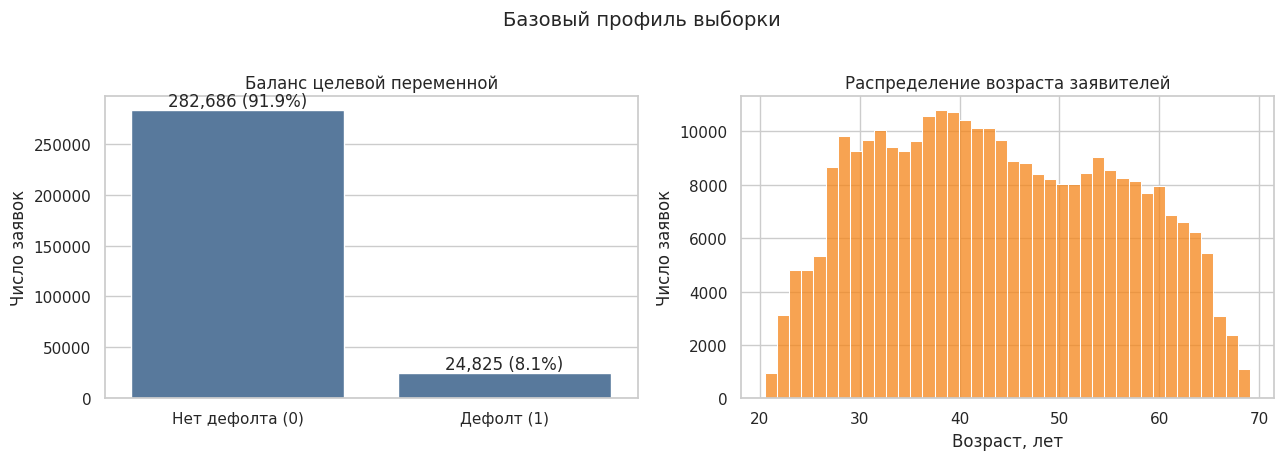

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
target_counts = application_train['TARGET'].value_counts().sort_index()
sns.barplot(x=['Нет дефолта (0)', 'Дефолт (1)'], y=target_counts.values, ax=axes[0], color='#4C78A8')
axes[0].set(title='Баланс целевой переменной', xlabel='', ylabel='Число заявок')
for i, value in enumerate(target_counts.values):
    axes[0].text(i, value, f'{value:,} ({value / len(application_train):.1%})', ha='center', va='bottom')
age = -application_train['DAYS_BIRTH'] / 365.25
sns.histplot(age, bins=40, color='#F58518', ax=axes[1])
axes[1].set(title='Распределение возраста заявителей', xlabel='Возраст, лет', ylabel='Число заявок')
fig.suptitle('Базовый профиль выборки', y=1.02, fontsize=14)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '01_target_and_age.png', dpi=160, bbox_inches='tight')
plt.show()

Дефолтный класс занимает только **8.07%** выборки. Поэтому accuracy здесь легко получить высокой даже у почти бесполезной модели, и дальше основными метриками остаются ROC-AUC и PR-AUC. `SK_ID_CURR` уникален, так что отдельная дедупликация заявок не требуется.

Значение `DAYS_EMPLOYED = 365243` встречается у 55 374 клиентов и явно является техническим кодом, а не реальным стажем. В feature engineering это значение заменяется на пропуск, а сам факт аномалии сохраняется отдельным бинарным признаком.

### 2.2. Пропуски, выбросы и аномальные значения

Дальше смотрю пропуски, распределения и экстремальные значения. Разреженные колонки не удаляю автоматически: отсутствие внешнего скоринга, сведений о жилье или кредитной истории само может быть сигналом.

Правдоподобные большие суммы дохода, кредита и аннуитета тоже не удаляю только потому, что они попали в хвост распределения. Для денежных признаков дальше добавляю `log1p`, чтобы уменьшить влияние длинных хвостов на линейную модель и MLP. Явное техническое значение `DAYS_EMPLOYED=365243` обрабатываю отдельно: заменяю на пропуск и сохраняю флаг аномалии.

In [4]:
feature_types = application_train.drop(columns='TARGET').dtypes.value_counts().rename_axis('dtype').reset_index(name='n_features')
display(feature_types)
missingness = application_train.drop(columns='TARGET').isna().mean().sort_values(ascending=False).rename('missing_rate').to_frame()
missingness['missing_count'] = (missingness['missing_rate'] * len(application_train)).round().astype(int)
display(missingness.head(20).style.format({'missing_rate': '{:.1%}'}).set_caption('20 признаков с наибольшей долей пропусков'))
key_numeric = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'DAYS_EMPLOYED', 'DAYS_BIRTH']
display(application_train[key_numeric].describe(percentiles=[.01, .05, .5, .95, .99]).T)
quality_checks = pd.DataFrame({
    'check': ['Отрицательный доход', 'Нулевой/отрицательный кредит', 'Нулевой/отрицательный аннуитет', 'Возраст < 18', 'Возраст > 100', 'XNA в CODE_GENDER'],
    'count': [(application_train['AMT_INCOME_TOTAL'] <= 0).sum(), (application_train['AMT_CREDIT'] <= 0).sum(), (application_train['AMT_ANNUITY'].fillna(1) <= 0).sum(), ((-application_train['DAYS_BIRTH'] / 365.25) < 18).sum(), ((-application_train['DAYS_BIRTH'] / 365.25) > 100).sum(), (application_train['CODE_GENDER'] == 'XNA').sum()],
})
quality_checks['rate'] = quality_checks['count'] / len(application_train)
display(quality_checks.style.format({'rate': '{:.3%}'}))

,dtype,n_features
0,float64,65
1,int64,40
2,object,16


,missing_rate,missing_count
COMMONAREA_AVG,69.9%,214865
COMMONAREA_MEDI,69.9%,214865
COMMONAREA_MODE,69.9%,214865
NONLIVINGAPARTMENTS_AVG,69.4%,213514
NONLIVINGAPARTMENTS_MEDI,69.4%,213514
NONLIVINGAPARTMENTS_MODE,69.4%,213514
FONDKAPREMONT_MODE,68.4%,210295
LIVINGAPARTMENTS_MEDI,68.4%,210199
LIVINGAPARTMENTS_AVG,68.4%,210199
LIVINGAPARTMENTS_MODE,68.4%,210199


,count,mean,std,min,1%,5%,50%,95%,99%,max
AMT_INCOME_TOTAL,"307,511.0000","168,797.9193","237,123.1463","25,650.0000","45,000.0000","67,500.0000","147,150.0000","337,500.0000","472,500.0000","117,000,000.0000"
AMT_CREDIT,"307,511.0000","599,025.9997","402,490.7770","45,000.0000","76,410.0000","135,000.0000","513,531.0000","1,350,000.0000","1,854,000.0000","4,050,000.0000"
AMT_ANNUITY,"307,499.0000","27,108.5739","14,493.7373","1,615.5000","6,182.9100","9,000.0000","24,903.0000","53,325.0000","70,006.5000","258,025.5000"
DAYS_EMPLOYED,"307,511.0000","63,815.0459","141,275.7665","-17,912.0000","-10,894.9000","-6,742.5000","-1,213.0000","365,243.0000","365,243.0000","365,243.0000"
DAYS_BIRTH,"307,511.0000","-16,036.9951","4,363.9886","-25,229.0000","-24,419.0000","-23,204.0000","-15,750.0000","-9,407.0000","-8,263.0000","-7,489.0000"


,check,count,rate
0,Отрицательный доход,0,0.000%
1,Нулевой/отрицательный кредит,0,0.000%
2,Нулевой/отрицательный аннуитет,0,0.000%
3,Возраст < 18,0,0.000%
4,Возраст > 100,0,0.000%
5,XNA в CODE_GENDER,4,0.001%


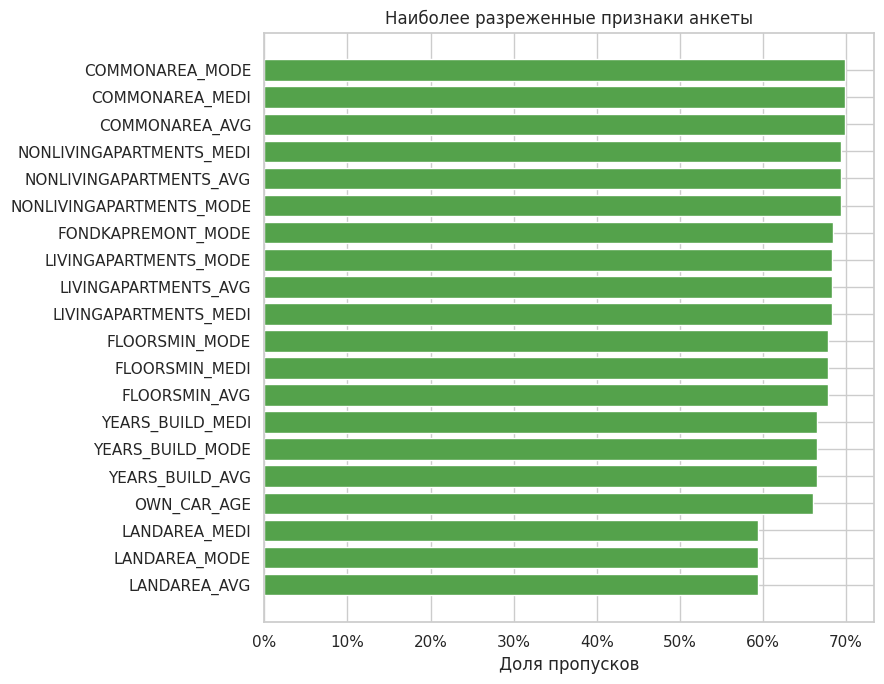

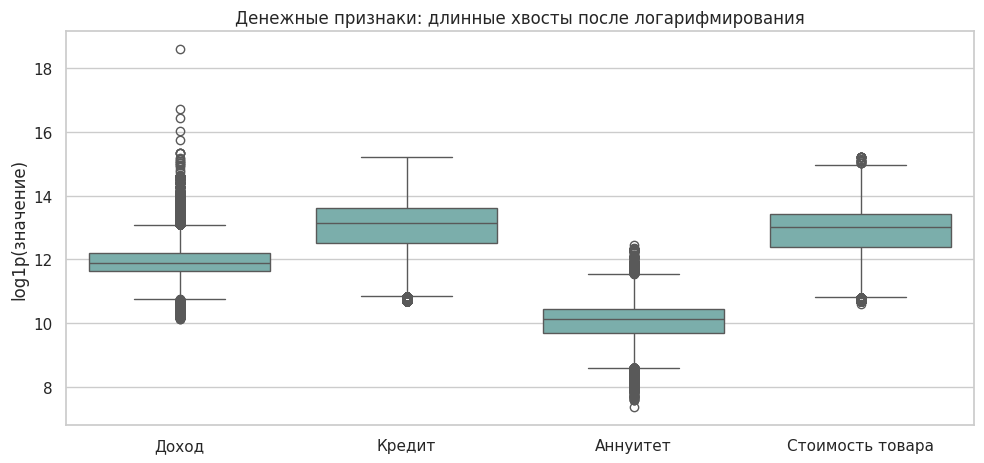

In [5]:
top_missing = missingness.head(20).sort_values('missing_rate')
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top_missing.index, top_missing['missing_rate'], color='#54A24B')
ax.set(title='Наиболее разреженные признаки анкеты', xlabel='Доля пропусков', ylabel='')
ax.xaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '02_missingness.png', dpi=160, bbox_inches='tight')
plt.show()

# Boxplot нужен не только формально: он показывает длинные хвосты денежных признаков.
amount_columns = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']
amounts_long = (
    np.log1p(application_train[amount_columns].clip(lower=0))
    .rename(columns={
        'AMT_INCOME_TOTAL': 'Доход',
        'AMT_CREDIT': 'Кредит',
        'AMT_ANNUITY': 'Аннуитет',
        'AMT_GOODS_PRICE': 'Стоимость товара',
    })
    .melt(var_name='Признак', value_name='log1p(значение)')
)
fig, ax = plt.subplots(figsize=(10, 4.8))
sns.boxplot(data=amounts_long, x='Признак', y='log1p(значение)', ax=ax, color='#72B7B2')
ax.set(title='Денежные признаки: длинные хвосты после логарифмирования', xlabel='', ylabel='log1p(значение)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '02b_amount_boxplots.png', dpi=160, bbox_inches='tight')
plt.show()

### 2.3. Какие признаки связаны с дефолтом

Теперь смотрю несколько понятных зависимостей: возраст, доход, размер кредита и внешние скоринги. Эти графики нужны не для причинных выводов, а чтобы понять, какие преобразования стоит проверить дальше.

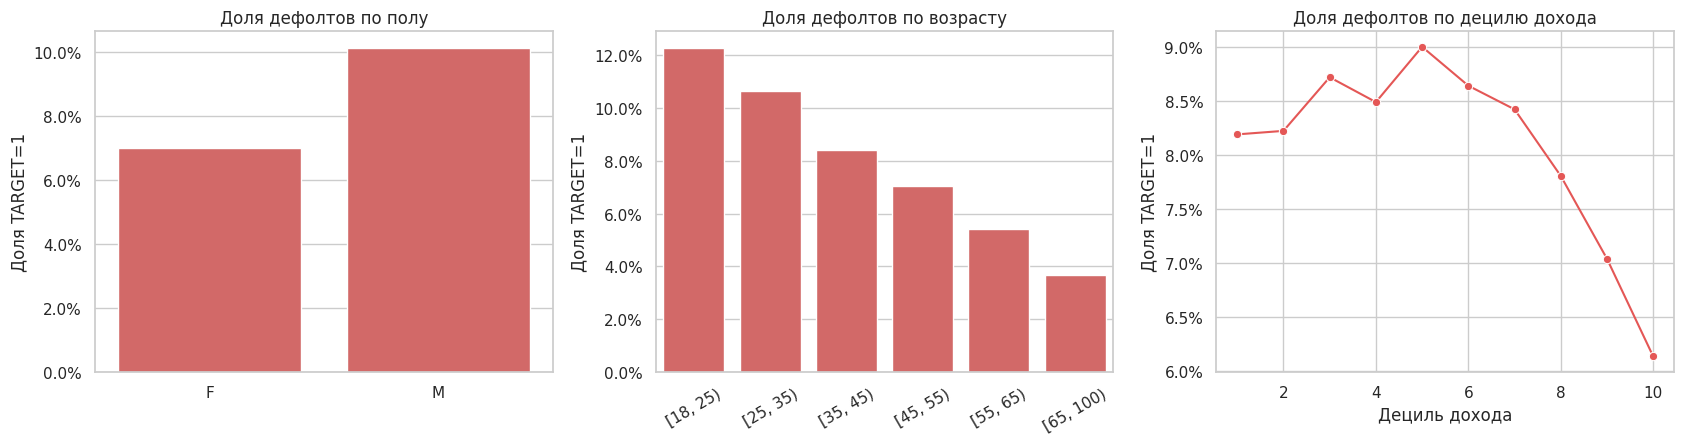


Пол


,mean,size
CODE_GENDER,,
F,7.00%,202448
M,10.14%,105059



Возраст


,mean,size
age_group,,
"[18, 25)",12.29%,12233
"[25, 35)",10.66%,72429
"[35, 45)",8.41%,84261
"[45, 55)",7.05%,70190
"[55, 65)",5.42%,60522
"[65, 100)",3.66%,7876



Доход


,mean,size
income_decile,,
1,8.19%,33391
2,8.22%,30280
3,8.72%,36907
4,8.49%,48849
5,9.00%,4333
6,8.64%,31120
7,8.42%,30704
8,7.81%,44809
9,7.04%,19957


Категория XNA не показана на графике пола: в ней всего 4 заявки.


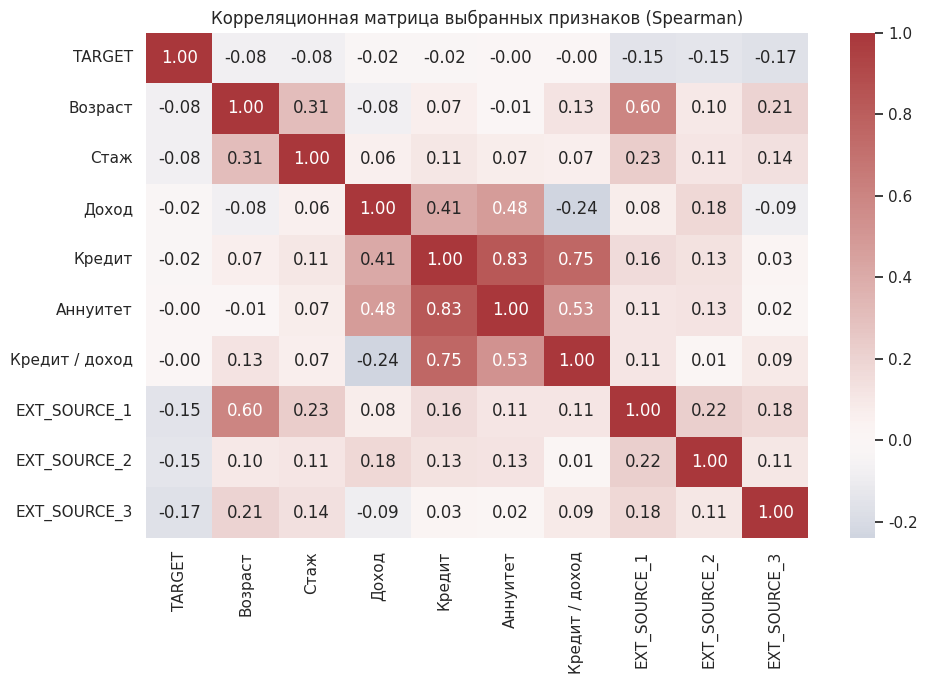

In [6]:
eda_frame = application_train.assign(
    age_years=-application_train['DAYS_BIRTH'] / 365.25,
    employment_years=np.where(
        application_train['DAYS_EMPLOYED'].eq(365243),
        np.nan,
        -application_train['DAYS_EMPLOYED'] / 365.25,
    ),
    credit_to_income=(
        application_train['AMT_CREDIT']
        / application_train['AMT_INCOME_TOTAL'].clip(lower=1)
    ),
)
eda_frame['age_group'] = pd.cut(
    eda_frame['age_years'],
    bins=[18, 25, 35, 45, 55, 65, 100],
    right=False,
)
eda_frame['income_decile'] = pd.qcut(
    eda_frame['AMT_INCOME_TOTAL'],
    q=10,
    duplicates='drop',
    labels=range(1, 11),
)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

gender_risk = (
    eda_frame.loc[eda_frame['CODE_GENDER'].ne('XNA')]
    .groupby('CODE_GENDER', observed=False)['TARGET']
    .agg(['mean', 'size'])
    .reset_index()
)
sns.barplot(data=gender_risk, x='CODE_GENDER', y='mean', color='#E45756', ax=axes[0])
axes[0].set(title='Доля дефолтов по полу', xlabel='', ylabel='Доля TARGET=1')

age_risk = (
    eda_frame.groupby('age_group', observed=False)['TARGET']
    .agg(['mean', 'size'])
    .reset_index()
)
sns.barplot(data=age_risk, x='age_group', y='mean', color='#E45756', ax=axes[1])
axes[1].set(title='Доля дефолтов по возрасту', xlabel='', ylabel='Доля TARGET=1')
axes[1].tick_params(axis='x', rotation=30)

income_risk = (
    eda_frame.groupby('income_decile', observed=False)['TARGET']
    .agg(['mean', 'size'])
    .reset_index()
)
sns.lineplot(data=income_risk, x='income_decile', y='mean', marker='o', color='#E45756', ax=axes[2])
axes[2].set(title='Доля дефолтов по децилю дохода', xlabel='Дециль дохода', ylabel='Доля TARGET=1')

for axis in axes:
    axis.yaxis.set_major_formatter(lambda value, _: f'{value:.1%}')

fig.tight_layout()
fig.savefig(FIGURES_DIR / '03_risk_segments.png', dpi=160, bbox_inches='tight')
plt.show()

for name, table in {
    'Пол': gender_risk.set_index('CODE_GENDER'),
    'Возраст': age_risk.set_index('age_group'),
    'Доход': income_risk.set_index('income_decile'),
}.items():
    print(f'\n{name}')
    display(table.style.format({'mean': '{:.2%}'}))

print('Категория XNA не показана на графике пола: в ней всего 4 заявки.')

# Корреляции смотрю на небольшом наборе интерпретируемых признаков.
# Spearman устойчивее Pearson к длинным хвостам и нелинейной монотонной связи.
corr_frame = pd.DataFrame({
    'TARGET': eda_frame['TARGET'],
    'Возраст': eda_frame['age_years'],
    'Стаж': eda_frame['employment_years'],
    'Доход': eda_frame['AMT_INCOME_TOTAL'],
    'Кредит': eda_frame['AMT_CREDIT'],
    'Аннуитет': eda_frame['AMT_ANNUITY'],
    'Кредит / доход': eda_frame['credit_to_income'],
    'EXT_SOURCE_1': eda_frame['EXT_SOURCE_1'],
    'EXT_SOURCE_2': eda_frame['EXT_SOURCE_2'],
    'EXT_SOURCE_3': eda_frame['EXT_SOURCE_3'],
})
corr = corr_frame.corr(method='spearman')
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, cmap='vlag', center=0, annot=True, fmt='.2f', square=False, ax=ax)
ax.set_title('Корреляционная матрица выбранных признаков (Spearman)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '03b_correlation_matrix.png', dpi=160, bbox_inches='tight')
plt.show()

### 2.4. Насколько полная кредитная история

Перед объединением таблиц проверяю, для какой доли клиентов вообще есть записи в `bureau`, прошлых заявках, POS, рассрочках и кредитных картах. Отсутствие записи считаю нормальным состоянием, а не поводом удалять клиента.

In [7]:
source_specs = {'bureau.csv': 'SK_ID_CURR', 'previous_application.csv': 'SK_ID_CURR', 'POS_CASH_balance.csv': 'SK_ID_CURR', 'installments_payments.csv': 'SK_ID_CURR', 'credit_card_balance.csv': 'SK_ID_CURR'}
train_id_set = set(application_train['SK_ID_CURR'])
test_id_set = set(application_test['SK_ID_CURR'])
all_application_ids = train_id_set | test_id_set
source_coverage_rows = []
for filename, key in source_specs.items():
    ids = pd.read_csv(DATA_DIR / filename, usecols=[key])[key]
    unique_ids = set(ids.unique())
    unknown_ids = unique_ids - all_application_ids
    source_coverage_rows.append({
        'source': filename,
        'rows': len(ids),
        'unique_clients': len(unique_ids),
        'coverage_train_clients': len(unique_ids & train_id_set) / len(train_id_set),
        'coverage_test_clients': len(unique_ids & test_id_set) / len(test_id_set),
        'unknown_client_ids': len(unknown_ids),
        'mean_rows_per_client': len(ids) / len(unique_ids),
    })
source_coverage = pd.DataFrame(source_coverage_rows)
display(source_coverage.style.format({'coverage_train_clients': '{:.2%}', 'coverage_test_clients': '{:.2%}', 'mean_rows_per_client': '{:.1f}'}).set_caption('Покрытие заявителей и ссылочная целостность вспомогательных источников'))
assert source_coverage['unknown_client_ids'].eq(0).all(), 'Во внешних таблицах найдены ID, которых нет среди заявок train/test'

,source,rows,unique_clients,coverage_train_clients,coverage_test_clients,unknown_client_ids,mean_rows_per_client
0,bureau.csv,1716428,305811,85.69%,86.82%,0,5.6
1,previous_application.csv,1670214,338857,94.65%,98.06%,0,4.9
2,POS_CASH_balance.csv,10001358,337252,94.12%,98.08%,0,29.7
3,installments_payments.csv,13605401,339587,94.84%,98.36%,0,40.1
4,credit_card_balance.csv,3840312,103558,28.26%,34.16%,0,37.1


Исторические источники покрывают клиентов по-разному. Прошлые заявки, POS и рассрочки есть примерно у 94–95% train-клиентов, `bureau` — примерно у 86%, а история кредитных карт только у 28%.

При этом неизвестных `SK_ID_CURR` во вспомогательных таблицах нет. Значит, отсутствие записи в конкретном источнике — нормальная часть данных, а не ошибка объединения. Поскольку на одного клиента приходится много исторических строк, перед merge все дополнительные таблицы агрегируются до одной строки на `SK_ID_CURR`.

### Что беру из EDA

Дефолтный класс занимает около 8%, поэтому дальше не ориентируюсь на accuracy как на основную метрику. `DAYS_EMPLOYED=365243` считаю техническим значением и заменяю на пропуск, сохраняя отдельный флаг.

Реальные большие суммы дохода и кредита не удаляю автоматически: для денежных признаков добавлю логарифмы и отношения. Разреженные признаки тоже сохраняю — отсутствие внешнего скоринга или истории само по себе может быть информативно.

Исторические таблицы покрывают клиентов по-разному, поэтому кроме агрегатов далее будут полезны и признаки количества записей.

## 3. Подготовка признаков

Сначала определяю общие функции для чтения и агрегации, затем отдельно собираю признаки анкеты и признаки из исторических таблиц.

In [8]:
def reduce_memory_usage(frame: pd.DataFrame) -> pd.DataFrame:
    """Снижает расход памяти для числовых признаков; исходные CSV не изменяет."""
    for column in frame.columns:
        dtype = frame[column].dtype
        if pd.api.types.is_integer_dtype(dtype):
            frame[column] = pd.to_numeric(frame[column], downcast='integer')
        elif pd.api.types.is_float_dtype(dtype):
            frame[column] = pd.to_numeric(frame[column], downcast='float')
    return frame


def read_source(filename: str) -> pd.DataFrame:
    """Читает один исходный CSV и уменьшает расход памяти."""
    frame = pd.read_csv(DATA_DIR / filename)
    return reduce_memory_usage(frame)


def flatten_aggregation(columns, prefix: str) -> list[str]:
    return [
        f'{prefix}__{feature}__{stat}'.upper()
        for feature, stat in columns
    ]


def aggregate_numeric(
    frame: pd.DataFrame,
    key: str,
    prefix: str,
    stats=('mean', 'max', 'min', 'sum', 'var'),
) -> pd.DataFrame:
    """Сводит таблицу к одному наблюдению на ключ и сохраняет число исходных строк."""
    excluded = {key, 'SK_ID_BUREAU', 'SK_ID_PREV', 'SK_ID_CURR'}
    numeric = [
        column
        for column in frame.select_dtypes(include=np.number).columns
        if column not in excluded
    ]
    grouped = frame.groupby(key, observed=True)
    counts = grouped.size().rename(f'{prefix}__ROW_COUNT'.upper())

    if not numeric:
        return counts.reset_index()

    result = grouped[numeric].agg(stats)
    result.columns = flatten_aggregation(result.columns, prefix)
    return result.join(counts).reset_index()


def aggregate_categories(
    frame: pd.DataFrame,
    key: str,
    prefix: str,
    max_levels: int = 40,
) -> pd.DataFrame:
    categorical = [
        column
        for column in frame.select_dtypes(
            include=['object', 'category']
        ).columns
        if frame[column].nunique(dropna=False) <= max_levels
    ]

    if not categorical:
        return frame[[key]].drop_duplicates().copy()

    dummies = pd.get_dummies(
        frame[categorical].fillna('__MISSING__'),
        prefix=categorical,
        dtype='float32',
    )
    dummies[key] = frame[key].to_numpy()

    result = dummies.groupby(key, observed=True).mean()
    result.columns = [
        f'{prefix}__{column}__MEAN'.upper()
        for column in result.columns
    ]
    return result.reset_index()


def merge_at_application_grain(
    base: pd.DataFrame,
    features: pd.DataFrame,
    source_name: str,
) -> pd.DataFrame:
    before = len(base)

    base = base.copy()
    features = features.copy()
    base['SK_ID_CURR'] = pd.Series(
        base['SK_ID_CURR'].to_numpy(dtype='int64'),
        index=base.index,
    )
    features['SK_ID_CURR'] = pd.Series(
        features['SK_ID_CURR'].to_numpy(dtype='int64'),
        index=features.index,
    )

    merged = base.merge(
        features,
        on='SK_ID_CURR',
        how='left',
        validate='one_to_one',
    )
    assert len(merged) == before, (
        f'{source_name}: нарушена гранулярность строк'
    )
    return merged


def safe_ratio(
    numerator: pd.Series,
    denominator: pd.Series,
) -> pd.Series:
    value = (
        numerator.astype('float32')
        / denominator.astype('float32').replace(0, np.nan)
    )
    return value.replace([np.inf, -np.inf], np.nan)


def aggregate_selected_numeric(
    frame: pd.DataFrame,
    key: str,
    prefix: str,
    columns: list[str],
    stats=('mean', 'max', 'sum'),
) -> pd.DataFrame:
    """Компактная агрегация выбранных полей."""
    available = [
        column for column in columns
        if column in frame.columns
    ]
    grouped = frame.groupby(key, observed=True)
    counts = grouped.size().rename(
        f'{prefix}__ROW_COUNT'.upper()
    )

    if not available:
        return counts.reset_index()

    result = grouped[available].agg(stats)
    result.columns = flatten_aggregation(
        result.columns,
        prefix,
    )
    return result.join(counts).reset_index()


def merge_feature_block(
    base: pd.DataFrame,
    block: pd.DataFrame,
    key: str = 'SK_ID_CURR',
) -> pd.DataFrame:
    """Добавляет ещё один агрегат к уже собранным признакам клиента."""
    if block is None or block.empty:
        return base
    return base.merge(
        block,
        on=key,
        how='left',
        validate='one_to_one',
    )


def aggregate_time_windows(
    frame: pd.DataFrame,
    key: str,
    time_column: str,
    prefix: str,
    windows: list[tuple[int, str]],
    columns: list[str],
    stats=('mean', 'max', 'sum'),
) -> list[pd.DataFrame]:
    """
    Строит одинаковые агрегаты на нескольких временных окнах.
    В Home Credit даты/месяцы заданы отрицательными значениями:
    чем ближе значение к нулю, тем событие свежее.
    """
    blocks = []

    for window, label in windows:
        subset = frame.loc[
            frame[time_column].ge(-window)
        ]
        if subset.empty:
            continue

        blocks.append(
            aggregate_selected_numeric(
                subset,
                key,
                f'{prefix}_V2_RECENT_{label}',
                columns,
                stats=stats,
            )
        )

    return blocks


def aggregate_last_n(
    frame: pd.DataFrame,
    key: str,
    order_column: str,
    prefix: str,
    columns: list[str],
    n_values=(1, 3, 5),
) -> list[pd.DataFrame]:
    """
    Берёт последние N записей клиента по временной колонке.
    Используется для сравнительно небольших bureau/previous,
    где глобальная сортировка не слишком дорога.
    """
    available = [
        column for column in columns
        if column in frame.columns
    ]
    if not available:
        return []

    ordered = frame.sort_values(
        [key, order_column],
        ascending=[True, False],
        kind='mergesort',
    )

    blocks = []
    for n in n_values:
        subset = ordered.groupby(
            key,
            observed=True,
            sort=False,
        ).head(n)

        stats = ('mean',) if n == 1 else (
            'mean', 'max', 'min'
        )
        blocks.append(
            aggregate_selected_numeric(
                subset,
                key,
                f'{prefix}_V2_LAST_{n}',
                available,
                stats=stats,
            )
        )

    return blocks


def aggregate_contract_profiles(
    frame: pd.DataFrame,
    prefix: str,
    columns: list[str],
    contract_key: str = 'SK_ID_PREV',
) -> pd.DataFrame | None:
    """
    Сначала описывает каждый отдельный прошлый кредит/договор,
    затем агрегирует договоры клиента до SK_ID_CURR.

    Это сохраняет часть структуры истории, которая теряется
    при прямой агрегации миллионов платежей сразу до клиента.
    """
    required = {'SK_ID_CURR', contract_key}
    if not required.issubset(frame.columns):
        return None

    available = [
        column for column in columns
        if column in frame.columns
    ]
    if not available:
        return None

    per_contract = (
        frame.groupby(
            ['SK_ID_CURR', contract_key],
            observed=True,
        )[available]
        .agg(['mean', 'max', 'sum'])
    )
    per_contract.columns = flatten_aggregation(
        per_contract.columns,
        f'{prefix}_V2_CONTRACT',
    )
    per_contract = per_contract.reset_index()

    contract_count = (
        per_contract.groupby(
            'SK_ID_CURR',
            observed=True,
        ).size()
        .rename(
            f'{prefix}_V2_CONTRACT__COUNT'.upper()
        )
    )

    contract_columns = [
        column for column in per_contract.columns
        if column not in {'SK_ID_CURR', contract_key}
    ]

    result = (
        per_contract.groupby(
            'SK_ID_CURR',
            observed=True,
        )[contract_columns]
        .agg(['mean', 'max', 'sum'])
    )
    result.columns = flatten_aggregation(
        result.columns,
        f'{prefix}_V2_CLIENT',
    )
    result = result.join(contract_count).reset_index()

    del per_contract
    gc.collect()
    return reduce_memory_usage(result)


def add_ratio_if_available(
    frame: pd.DataFrame,
    name: str,
    numerator: str,
    denominator: str,
) -> None:
    """Добавляет отношение уже агрегированных признаков, если обе колонки существуют."""
    if (
        numerator in frame.columns
        and denominator in frame.columns
    ):
        frame[name] = safe_ratio(
            frame[numerator],
            frame[denominator],
        )


In [9]:
def enrich_application(frame: pd.DataFrame) -> pd.DataFrame:
    """Строит признаки из текущей анкеты на момент подачи заявки."""
    result = frame.copy()

    result['APP__EMPLOYMENT_ANOMALY'] = (
        result['DAYS_EMPLOYED'].eq(365243).astype('int8')
    )
    result['DAYS_EMPLOYED'] = result[
        'DAYS_EMPLOYED'
    ].replace(365243, np.nan)

    result['APP__AGE_YEARS'] = (
        -result['DAYS_BIRTH'] / 365.25
    )
    result['APP__EMPLOYMENT_YEARS'] = (
        -result['DAYS_EMPLOYED'] / 365.25
    )
    result['APP__REGISTRATION_YEARS'] = (
        -result['DAYS_REGISTRATION'] / 365.25
    )
    result['APP__ID_PUBLISH_YEARS'] = (
        -result['DAYS_ID_PUBLISH'] / 365.25
    )
    result['APP__PHONE_CHANGE_YEARS'] = (
        -result['DAYS_LAST_PHONE_CHANGE'] / 365.25
    )
    result['APP__AGE_AT_EMPLOYMENT_START'] = (
        result['APP__AGE_YEARS']
        - result['APP__EMPLOYMENT_YEARS']
    )

    result['APP__CREDIT_TO_INCOME'] = safe_ratio(
        result['AMT_CREDIT'],
        result['AMT_INCOME_TOTAL'],
    )
    result['APP__ANNUITY_TO_INCOME'] = safe_ratio(
        result['AMT_ANNUITY'],
        result['AMT_INCOME_TOTAL'],
    )
    result['APP__CREDIT_TO_ANNUITY'] = safe_ratio(
        result['AMT_CREDIT'],
        result['AMT_ANNUITY'],
    )
    result['APP__PAYMENT_RATE'] = safe_ratio(
        result['AMT_ANNUITY'],
        result['AMT_CREDIT'],
    )
    result['APP__GOODS_TO_CREDIT'] = safe_ratio(
        result['AMT_GOODS_PRICE'],
        result['AMT_CREDIT'],
    )
    result['APP__CREDIT_PER_PERSON'] = safe_ratio(
        result['AMT_CREDIT'],
        result['CNT_FAM_MEMBERS'],
    )
    result['APP__INCOME_PER_PERSON'] = safe_ratio(
        result['AMT_INCOME_TOTAL'],
        result['CNT_FAM_MEMBERS'],
    )
    result['APP__INCOME_PER_CHILD'] = safe_ratio(
        result['AMT_INCOME_TOTAL'],
        result['CNT_CHILDREN'] + 1,
    )
    result['APP__CHILD_TO_FAMILY'] = safe_ratio(
        result['CNT_CHILDREN'],
        result['CNT_FAM_MEMBERS'],
    )
    result['APP__EMPLOYED_TO_AGE'] = safe_ratio(
        result['APP__EMPLOYMENT_YEARS'],
        result['APP__AGE_YEARS'],
    )

    # v2: стоимость товара и размер финансирования.
    result['APP__V2_CREDIT_GOODS_GAP'] = (
        result['AMT_CREDIT']
        - result['AMT_GOODS_PRICE']
    )
    result['APP__V2_CREDIT_GOODS_GAP_RATIO'] = (
        safe_ratio(
            result['APP__V2_CREDIT_GOODS_GAP'],
            result['AMT_GOODS_PRICE'],
        )
    )
    result['APP__V2_ANNUITY_TO_GOODS'] = safe_ratio(
        result['AMT_ANNUITY'],
        result['AMT_GOODS_PRICE'],
    )

    ext_sources = [
        'EXT_SOURCE_1',
        'EXT_SOURCE_2',
        'EXT_SOURCE_3',
    ]
    result['APP__EXT_SOURCE_MEAN'] = (
        result[ext_sources].mean(axis=1)
    )
    result['APP__EXT_SOURCE_STD'] = (
        result[ext_sources].std(axis=1)
    )
    result['APP__EXT_SOURCE_MIN'] = (
        result[ext_sources].min(axis=1)
    )
    result['APP__EXT_SOURCE_MAX'] = (
        result[ext_sources].max(axis=1)
    )
    result['APP__EXT_SOURCE_RANGE'] = (
        result['APP__EXT_SOURCE_MAX']
        - result['APP__EXT_SOURCE_MIN']
    )
    result['APP__EXT_SOURCE_AVAILABLE'] = (
        result[ext_sources]
        .notna()
        .sum(axis=1)
        .astype('int8')
    )

    # v2: взаимодействия внешних score.
    result['APP__V2_EXT_1_X_2'] = (
        result['EXT_SOURCE_1']
        * result['EXT_SOURCE_2']
    )
    result['APP__V2_EXT_1_X_3'] = (
        result['EXT_SOURCE_1']
        * result['EXT_SOURCE_3']
    )
    result['APP__V2_EXT_2_X_3'] = (
        result['EXT_SOURCE_2']
        * result['EXT_SOURCE_3']
    )
    result['APP__V2_EXT_PRODUCT'] = (
        result[ext_sources].prod(
            axis=1,
            min_count=3,
        )
    )
    result['APP__V2_EXT_MEAN_X_AGE'] = (
        result['APP__EXT_SOURCE_MEAN']
        * result['APP__AGE_YEARS']
    )
    result['APP__V2_EXT_MEAN_X_CREDIT_TO_INCOME'] = (
        result['APP__EXT_SOURCE_MEAN']
        * result['APP__CREDIT_TO_INCOME']
    )

    result['APP__CONTACT_FLAGS_SUM'] = result[[
        'FLAG_MOBIL',
        'FLAG_EMP_PHONE',
        'FLAG_WORK_PHONE',
        'FLAG_CONT_MOBILE',
        'FLAG_PHONE',
        'FLAG_EMAIL',
    ]].sum(axis=1)

    result['APP__DOCUMENT_FLAGS_SUM'] = result[[
        column
        for column in result
        if column.startswith('FLAG_DOCUMENT_')
    ]].sum(axis=1)

    result['APP__REGION_MISMATCH_SUM'] = result[[
        column
        for column in result
        if '_REGION_NOT_' in column
        or '_CITY_NOT_' in column
    ]].sum(axis=1)

    result['APP__BUREAU_REQUESTS_SUM'] = result[[
        column
        for column in result
        if column.startswith(
            'AMT_REQ_CREDIT_BUREAU_'
        )
    ]].sum(axis=1)

    monetary = [
        'AMT_INCOME_TOTAL',
        'AMT_CREDIT',
        'AMT_ANNUITY',
        'AMT_GOODS_PRICE',
    ]
    for column in monetary:
        result[f'APP__LOG1P__{column}'] = (
            np.log1p(
                result[column].clip(lower=0)
            )
        )
        result[
            f'APP__{column}__MISSING'
        ] = result[column].isna().astype('int8')

    return reduce_memory_usage(result)


### 3.1. Бюро и прошлые заявки

Для бюро считаю кредитную нагрузку, просрочки, активные/закрытые кредиты и недавнюю историю. Для прошлых заявок — суммы, решения по заявкам и соотношения запрошенного и выданного кредита.

In [10]:
def bureau_features() -> pd.DataFrame:
    bureau = read_source('bureau.csv')
    balance = read_source('bureau_balance.csv')

    # bureau_balance v2: переводим статусы 1..5 в числовую тяжесть просрочки
    # и отдельно отмечаем наличие проблемного статуса.
    balance['BB__DPD_LEVEL'] = (
        pd.to_numeric(
            balance['STATUS'],
            errors='coerce',
        )
        .fillna(0)
        .clip(lower=0)
        .astype('float32')
    )
    balance['BB__LATE_FLAG'] = (
        balance['STATUS']
        .isin(['1', '2', '3', '4', '5'])
        .astype('int8')
    )

    balance_numeric = aggregate_numeric(
        balance,
        'SK_ID_BUREAU',
        'BUREAU_BALANCE',
        stats=('mean', 'max', 'min', 'sum', 'var'),
    )
    balance_categories = aggregate_categories(
        balance,
        'SK_ID_BUREAU',
        'BUREAU_BALANCE',
    )
    balance_level = balance_numeric.merge(
        balance_categories,
        on='SK_ID_BUREAU',
        how='left',
        validate='one_to_one',
    )

    # Более свежие состояния конкретного кредита.
    balance_windows = aggregate_time_windows(
        balance,
        'SK_ID_BUREAU',
        'MONTHS_BALANCE',
        'BUREAU_BALANCE',
        windows=[
            (6, '6M'),
            (12, '12M'),
            (24, '24M'),
        ],
        columns=[
            'BB__DPD_LEVEL',
            'BB__LATE_FLAG',
        ],
        stats=('mean', 'max', 'sum'),
    )
    for block in balance_windows:
        balance_level = merge_feature_block(
            balance_level,
            block,
            key='SK_ID_BUREAU',
        )

    bureau['SK_ID_BUREAU'] = (
        bureau['SK_ID_BUREAU'].astype('int64')
    )
    balance_level['SK_ID_BUREAU'] = (
        balance_level['SK_ID_BUREAU']
        .astype('int64')
    )

    bureau = bureau.merge(
        balance_level,
        on='SK_ID_BUREAU',
        how='left',
        validate='one_to_one',
    )

    del (
        balance,
        balance_numeric,
        balance_categories,
        balance_level,
        balance_windows,
    )
    gc.collect()

    bureau['BUREAU__DEBT_TO_CREDIT'] = safe_ratio(
        bureau['AMT_CREDIT_SUM_DEBT'],
        bureau['AMT_CREDIT_SUM'],
    )
    bureau['BUREAU__OVERDUE_TO_CREDIT'] = safe_ratio(
        bureau['AMT_CREDIT_SUM_OVERDUE'],
        bureau['AMT_CREDIT_SUM'],
    )
    bureau['BUREAU__OVERDUE_TO_DEBT'] = safe_ratio(
        bureau['AMT_CREDIT_SUM_OVERDUE'],
        bureau['AMT_CREDIT_SUM_DEBT'],
    )
    bureau['BUREAU__LIMIT_TO_CREDIT'] = safe_ratio(
        bureau['AMT_CREDIT_SUM_LIMIT'],
        bureau['AMT_CREDIT_SUM'],
    )
    bureau['BUREAU__HAS_OVERDUE'] = (
        bureau['AMT_CREDIT_SUM_OVERDUE']
        .gt(0)
        .astype('int8')
    )
    bureau['BUREAU__PROLONGED_FLAG'] = (
        bureau['CNT_CREDIT_PROLONG']
        .gt(0)
        .astype('int8')
    )
    bureau['BUREAU__ENDDATE_GAP'] = (
        bureau['DAYS_ENDDATE_FACT']
        - bureau['DAYS_CREDIT_ENDDATE']
    )

    numeric = aggregate_numeric(
        bureau,
        'SK_ID_CURR',
        'BUREAU',
    )
    categories = aggregate_categories(
        bureau,
        'SK_ID_CURR',
        'BUREAU',
    )
    result = numeric.merge(
        categories,
        on='SK_ID_CURR',
        how='left',
        validate='one_to_one',
    )

    for status, suffix in [
        ('Active', 'ACTIVE'),
        ('Closed', 'CLOSED'),
    ]:
        subset = bureau.loc[
            bureau['CREDIT_ACTIVE'].eq(status)
        ]
        if not subset.empty:
            result = merge_feature_block(
                result,
                aggregate_numeric(
                    subset,
                    'SK_ID_CURR',
                    f'BUREAU_{suffix}',
                ),
            )

    # v1 окна оставляем для сопоставимости.
    for days, suffix in [
        (365, 'RECENT_365D'),
        (730, 'RECENT_730D'),
    ]:
        recent = bureau.loc[
            bureau['DAYS_CREDIT'].ge(-days)
        ]
        if not recent.empty:
            result = merge_feature_block(
                result,
                aggregate_selected_numeric(
                    recent,
                    'SK_ID_CURR',
                    f'BUREAU_{suffix}',
                    [
                        'AMT_CREDIT_SUM',
                        'AMT_CREDIT_SUM_DEBT',
                        'AMT_CREDIT_SUM_OVERDUE',
                        'BUREAU__HAS_OVERDUE',
                    ],
                ),
            )

    # v2: несколько временных горизонтов.
    bureau_window_columns = [
        'AMT_CREDIT_SUM',
        'AMT_CREDIT_SUM_DEBT',
        'AMT_CREDIT_SUM_OVERDUE',
        'AMT_CREDIT_SUM_LIMIT',
        'BUREAU__DEBT_TO_CREDIT',
        'BUREAU__OVERDUE_TO_DEBT',
        'BUREAU__HAS_OVERDUE',
        'CNT_CREDIT_PROLONG',
    ]
    for block in aggregate_time_windows(
        bureau,
        'SK_ID_CURR',
        'DAYS_CREDIT',
        'BUREAU',
        windows=[
            (180, '180D'),
            (365, '365D'),
            (730, '730D'),
            (1095, '1095D'),
        ],
        columns=bureau_window_columns,
        stats=('mean', 'max', 'sum'),
    ):
        result = merge_feature_block(
            result,
            block,
        )

    # v2: последние 1/3/5 кредитов клиента.
    for block in aggregate_last_n(
        bureau,
        'SK_ID_CURR',
        'DAYS_CREDIT',
        'BUREAU',
        columns=[
            'AMT_CREDIT_SUM',
            'AMT_CREDIT_SUM_DEBT',
            'AMT_CREDIT_SUM_OVERDUE',
            'BUREAU__DEBT_TO_CREDIT',
            'BUREAU__HAS_OVERDUE',
            'DAYS_CREDIT_ENDDATE',
        ],
        n_values=(1, 3, 5),
    ):
        result = merge_feature_block(
            result,
            block,
        )

    # v2: отношения уже на уровне клиента.
    add_ratio_if_available(
        result,
        'BUREAU__V2_TOTAL_DEBT_TO_CREDIT',
        'BUREAU__AMT_CREDIT_SUM_DEBT__SUM',
        'BUREAU__AMT_CREDIT_SUM__SUM',
    )
    add_ratio_if_available(
        result,
        'BUREAU__V2_TOTAL_OVERDUE_TO_DEBT',
        'BUREAU__AMT_CREDIT_SUM_OVERDUE__SUM',
        'BUREAU__AMT_CREDIT_SUM_DEBT__SUM',
    )
    add_ratio_if_available(
        result,
        'BUREAU__V2_RECENT_365_DEBT_SHARE',
        'BUREAU_V2_RECENT_365D__AMT_CREDIT_SUM_DEBT__SUM',
        'BUREAU__AMT_CREDIT_SUM_DEBT__SUM',
    )

    del bureau, numeric, categories
    gc.collect()
    return reduce_memory_usage(result)


def previous_application_features() -> pd.DataFrame:
    previous = read_source(
        'previous_application.csv'
    )

    day_columns = [
        'DAYS_FIRST_DRAWING',
        'DAYS_FIRST_DUE',
        'DAYS_LAST_DUE_1ST_VERSION',
        'DAYS_LAST_DUE',
        'DAYS_TERMINATION',
    ]
    previous[day_columns] = (
        previous[day_columns]
        .replace(365243, np.nan)
    )

    previous['PREV__APPLICATION_TO_CREDIT'] = safe_ratio(
        previous['AMT_APPLICATION'],
        previous['AMT_CREDIT'],
    )
    previous['PREV__DOWN_PAYMENT_TO_CREDIT'] = safe_ratio(
        previous['AMT_DOWN_PAYMENT'],
        previous['AMT_CREDIT'],
    )
    previous['PREV__CREDIT_TO_GOODS'] = safe_ratio(
        previous['AMT_CREDIT'],
        previous['AMT_GOODS_PRICE'],
    )
    previous['PREV__APPLICATION_GAP'] = (
        previous['AMT_APPLICATION']
        - previous['AMT_CREDIT']
    )
    previous['PREV__HAS_DOWN_PAYMENT'] = (
        previous['AMT_DOWN_PAYMENT']
        .gt(0)
        .astype('int8')
    )

    # v2: дополнительные отношения по прошлой заявке.
    previous['PREV__V2_CREDIT_TO_ANNUITY'] = safe_ratio(
        previous['AMT_CREDIT'],
        previous['AMT_ANNUITY'],
    )
    previous['PREV__V2_ANNUITY_TO_CREDIT'] = safe_ratio(
        previous['AMT_ANNUITY'],
        previous['AMT_CREDIT'],
    )
    previous['PREV__V2_CREDIT_GOODS_GAP'] = (
        previous['AMT_CREDIT']
        - previous['AMT_GOODS_PRICE']
    )

    numeric = aggregate_numeric(
        previous,
        'SK_ID_CURR',
        'PREVIOUS',
    )
    categories = aggregate_categories(
        previous,
        'SK_ID_CURR',
        'PREVIOUS',
    )
    result = numeric.merge(
        categories,
        on='SK_ID_CURR',
        how='left',
        validate='one_to_one',
    )

    for status, suffix in [
        ('Approved', 'APPROVED'),
        ('Refused', 'REFUSED'),
    ]:
        subset = previous.loc[
            previous['NAME_CONTRACT_STATUS']
            .eq(status)
        ]
        if not subset.empty:
            result = merge_feature_block(
                result,
                aggregate_numeric(
                    subset,
                    'SK_ID_CURR',
                    f'PREVIOUS_{suffix}',
                ),
            )

    # v1 срез.
    recent = previous.loc[
        previous['DAYS_DECISION'].ge(-365)
    ]
    if not recent.empty:
        result = merge_feature_block(
            result,
            aggregate_selected_numeric(
                recent,
                'SK_ID_CURR',
                'PREVIOUS_RECENT_365D',
                [
                    'AMT_APPLICATION',
                    'AMT_CREDIT',
                    'AMT_ANNUITY',
                    'PREV__APPLICATION_GAP',
                ],
            ),
        )

    # v2: одинаковые горизонты.
    previous_window_columns = [
        'AMT_APPLICATION',
        'AMT_CREDIT',
        'AMT_ANNUITY',
        'AMT_GOODS_PRICE',
        'PREV__APPLICATION_GAP',
        'PREV__APPLICATION_TO_CREDIT',
        'PREV__CREDIT_TO_GOODS',
        'PREV__V2_CREDIT_TO_ANNUITY',
    ]
    for block in aggregate_time_windows(
        previous,
        'SK_ID_CURR',
        'DAYS_DECISION',
        'PREVIOUS',
        windows=[
            (180, '180D'),
            (365, '365D'),
            (730, '730D'),
            (1095, '1095D'),
        ],
        columns=previous_window_columns,
        stats=('mean', 'max', 'sum'),
    ):
        result = merge_feature_block(
            result,
            block,
        )

    # Последние 1/3/5 заявок.
    for block in aggregate_last_n(
        previous,
        'SK_ID_CURR',
        'DAYS_DECISION',
        'PREVIOUS',
        columns=[
            'AMT_APPLICATION',
            'AMT_CREDIT',
            'AMT_ANNUITY',
            'PREV__APPLICATION_GAP',
            'PREV__APPLICATION_TO_CREDIT',
            'PREV__V2_CREDIT_TO_ANNUITY',
        ],
        n_values=(1, 3, 5),
    ):
        result = merge_feature_block(
            result,
            block,
        )

    del previous, numeric, categories
    gc.collect()
    return reduce_memory_usage(result)


### 3.2. POS, рассрочки и кредитные карты

Здесь интересуют прежде всего просрочки, фактические платежи, остатки, лимиты и использование кредитных карт.

In [11]:
def pos_cash_features() -> pd.DataFrame:
    pos = read_source('POS_CASH_balance.csv')

    pos['POS__LATE_PAYMENT_FLAG'] = (
        pos['SK_DPD'].gt(0).astype('int8')
    )
    pos['POS__SEVERE_LATE_FLAG'] = (
        pos['SK_DPD_DEF'].gt(0).astype('int8')
    )
    pos['POS__MONTHS_REMAINING_RATIO'] = safe_ratio(
        pos['CNT_INSTALMENT_FUTURE'],
        pos['CNT_INSTALMENT'],
    )

    numeric = aggregate_numeric(
        pos,
        'SK_ID_CURR',
        'POS',
    )
    categories = aggregate_categories(
        pos,
        'SK_ID_CURR',
        'POS',
    )
    result = numeric.merge(
        categories,
        on='SK_ID_CURR',
        how='left',
        validate='one_to_one',
    )

    # v1.
    recent = pos.loc[
        pos['MONTHS_BALANCE'].ge(-6)
    ]
    if not recent.empty:
        result = merge_feature_block(
            result,
            aggregate_selected_numeric(
                recent,
                'SK_ID_CURR',
                'POS_RECENT_6M',
                [
                    'SK_DPD',
                    'SK_DPD_DEF',
                    'CNT_INSTALMENT_FUTURE',
                    'POS__LATE_PAYMENT_FLAG',
                ],
            ),
        )

    # v2: недавнее поведение в нескольких окнах.
    for block in aggregate_time_windows(
        pos,
        'SK_ID_CURR',
        'MONTHS_BALANCE',
        'POS',
        windows=[
            (3, '3M'),
            (6, '6M'),
            (12, '12M'),
            (24, '24M'),
        ],
        columns=[
            'SK_DPD',
            'SK_DPD_DEF',
            'CNT_INSTALMENT_FUTURE',
            'POS__LATE_PAYMENT_FLAG',
            'POS__SEVERE_LATE_FLAG',
            'POS__MONTHS_REMAINING_RATIO',
        ],
        stats=('mean', 'max', 'sum'),
    ):
        result = merge_feature_block(
            result,
            block,
        )

    # v2: сначала описываем каждый отдельный POS-договор.
    contract_features = aggregate_contract_profiles(
        pos,
        'POS',
        columns=[
            'SK_DPD',
            'SK_DPD_DEF',
            'CNT_INSTALMENT_FUTURE',
            'POS__LATE_PAYMENT_FLAG',
            'POS__MONTHS_REMAINING_RATIO',
        ],
    )
    result = merge_feature_block(
        result,
        contract_features,
    )

    add_ratio_if_available(
        result,
        'POS__V2_RECENT_3M_DPD_TO_ALL',
        'POS_V2_RECENT_3M__SK_DPD__MEAN',
        'POS__SK_DPD__MEAN',
    )
    add_ratio_if_available(
        result,
        'POS__V2_RECENT_3M_LATE_TO_ALL',
        'POS_V2_RECENT_3M__POS__LATE_PAYMENT_FLAG__MEAN',
        'POS__POS__LATE_PAYMENT_FLAG__MEAN',
    )

    del pos, numeric, categories, contract_features
    gc.collect()
    return reduce_memory_usage(result)


def installments_features() -> pd.DataFrame:
    installments = read_source(
        'installments_payments.csv'
    )

    installments['INST__PAYMENT_DIFF'] = (
        installments['AMT_INSTALMENT']
        - installments['AMT_PAYMENT']
    )
    installments['INST__PAYMENT_RATIO'] = safe_ratio(
        installments['AMT_PAYMENT'],
        installments['AMT_INSTALMENT'],
    )
    installments['INST__DAYS_LATE'] = (
        installments['DAYS_ENTRY_PAYMENT']
        - installments['DAYS_INSTALMENT']
    ).clip(lower=0)
    installments['INST__DAYS_EARLY'] = (
        installments['DAYS_INSTALMENT']
        - installments['DAYS_ENTRY_PAYMENT']
    ).clip(lower=0)
    installments['INST__LATE_FLAG'] = (
        installments['INST__DAYS_LATE']
        .gt(0)
        .astype('int8')
    )
    installments['INST__UNDERPAID_FLAG'] = (
        installments['INST__PAYMENT_DIFF']
        .gt(0)
        .astype('int8')
    )

    numeric = aggregate_numeric(
        installments,
        'SK_ID_CURR',
        'INSTALLMENTS',
    )
    result = numeric

    # v1.
    recent = installments.loc[
        installments['DAYS_INSTALMENT'].ge(-365)
    ]
    if not recent.empty:
        result = merge_feature_block(
            result,
            aggregate_selected_numeric(
                recent,
                'SK_ID_CURR',
                'INSTALLMENTS_RECENT_365D',
                [
                    'INST__PAYMENT_DIFF',
                    'INST__PAYMENT_RATIO',
                    'INST__DAYS_LATE',
                    'INST__LATE_FLAG',
                    'INST__UNDERPAID_FLAG',
                ],
            ),
        )

    # v2: недавние платежи.
    for block in aggregate_time_windows(
        installments,
        'SK_ID_CURR',
        'DAYS_INSTALMENT',
        'INSTALLMENTS',
        windows=[
            (90, '90D'),
            (180, '180D'),
            (365, '365D'),
            (730, '730D'),
        ],
        columns=[
            'AMT_INSTALMENT',
            'AMT_PAYMENT',
            'INST__PAYMENT_DIFF',
            'INST__PAYMENT_RATIO',
            'INST__DAYS_LATE',
            'INST__LATE_FLAG',
            'INST__UNDERPAID_FLAG',
        ],
        stats=('mean', 'max', 'sum'),
    ):
        result = merge_feature_block(
            result,
            block,
        )

    # v2: платежи сначала сворачиваются до отдельного SK_ID_PREV,
    # затем договоры — до клиента.
    contract_features = aggregate_contract_profiles(
        installments,
        'INSTALLMENTS',
        columns=[
            'INST__PAYMENT_DIFF',
            'INST__PAYMENT_RATIO',
            'INST__DAYS_LATE',
            'INST__LATE_FLAG',
            'INST__UNDERPAID_FLAG',
        ],
    )
    result = merge_feature_block(
        result,
        contract_features,
    )

    add_ratio_if_available(
        result,
        'INSTALLMENTS__V2_RECENT_180D_LATE_TO_ALL',
        'INSTALLMENTS_V2_RECENT_180D__INST__DAYS_LATE__MEAN',
        'INSTALLMENTS__INST__DAYS_LATE__MEAN',
    )
    add_ratio_if_available(
        result,
        'INSTALLMENTS__V2_RECENT_180D_PAYMENT_RATIO_TO_ALL',
        'INSTALLMENTS_V2_RECENT_180D__INST__PAYMENT_RATIO__MEAN',
        'INSTALLMENTS__INST__PAYMENT_RATIO__MEAN',
    )

    del installments, numeric, contract_features
    gc.collect()
    return reduce_memory_usage(result)


def credit_card_features() -> pd.DataFrame:
    card = read_source(
        'credit_card_balance.csv'
    )

    card['CC__UTILIZATION'] = safe_ratio(
        card['AMT_BALANCE'],
        card['AMT_CREDIT_LIMIT_ACTUAL'],
    )
    card['CC__DRAWING_TO_LIMIT'] = safe_ratio(
        card['AMT_DRAWINGS_CURRENT'],
        card['AMT_CREDIT_LIMIT_ACTUAL'],
    )
    card['CC__PAYMENT_TO_BALANCE'] = safe_ratio(
        card['AMT_PAYMENT_CURRENT'],
        card['AMT_BALANCE'],
    )
    card['CC__MIN_PAYMENT_TO_BALANCE'] = safe_ratio(
        card['AMT_INST_MIN_REGULARITY'],
        card['AMT_BALANCE'],
    )
    card['CC__LATE_FLAG'] = (
        card['SK_DPD'].gt(0).astype('int8')
    )
    card['CC__OVER_LIMIT_FLAG'] = (
        card['AMT_BALANCE']
        .gt(card['AMT_CREDIT_LIMIT_ACTUAL'])
        .astype('int8')
    )

    numeric = aggregate_numeric(
        card,
        'SK_ID_CURR',
        'CREDIT_CARD',
    )
    result = numeric

    # v1.
    recent = card.loc[
        card['MONTHS_BALANCE'].ge(-6)
    ]
    if not recent.empty:
        result = merge_feature_block(
            result,
            aggregate_selected_numeric(
                recent,
                'SK_ID_CURR',
                'CREDIT_CARD_RECENT_6M',
                [
                    'AMT_BALANCE',
                    'AMT_DRAWINGS_CURRENT',
                    'CC__UTILIZATION',
                    'CC__LATE_FLAG',
                    'CC__OVER_LIMIT_FLAG',
                ],
            ),
        )

    # v2: несколько горизонтов.
    for block in aggregate_time_windows(
        card,
        'SK_ID_CURR',
        'MONTHS_BALANCE',
        'CREDIT_CARD',
        windows=[
            (3, '3M'),
            (6, '6M'),
            (12, '12M'),
            (24, '24M'),
        ],
        columns=[
            'AMT_BALANCE',
            'AMT_CREDIT_LIMIT_ACTUAL',
            'AMT_DRAWINGS_CURRENT',
            'AMT_PAYMENT_CURRENT',
            'CC__UTILIZATION',
            'CC__DRAWING_TO_LIMIT',
            'CC__PAYMENT_TO_BALANCE',
            'CC__LATE_FLAG',
            'CC__OVER_LIMIT_FLAG',
        ],
        stats=('mean', 'max', 'sum'),
    ):
        result = merge_feature_block(
            result,
            block,
        )

    # v2: сначала профиль каждой отдельной кредитной карты/договора.
    contract_features = aggregate_contract_profiles(
        card,
        'CREDIT_CARD',
        columns=[
            'AMT_BALANCE',
            'AMT_CREDIT_LIMIT_ACTUAL',
            'CC__UTILIZATION',
            'CC__PAYMENT_TO_BALANCE',
            'CC__LATE_FLAG',
        ],
    )
    result = merge_feature_block(
        result,
        contract_features,
    )

    add_ratio_if_available(
        result,
        'CREDIT_CARD__V2_RECENT_3M_UTIL_TO_ALL',
        'CREDIT_CARD_V2_RECENT_3M__CC__UTILIZATION__MEAN',
        'CREDIT_CARD__CC__UTILIZATION__MEAN',
    )
    add_ratio_if_available(
        result,
        'CREDIT_CARD__V2_RECENT_3M_LATE_TO_ALL',
        'CREDIT_CARD_V2_RECENT_3M__CC__LATE_FLAG__MEAN',
        'CREDIT_CARD__CC__LATE_FLAG__MEAN',
    )

    del card, numeric, contract_features
    gc.collect()
    return reduce_memory_usage(result)


### 3.3. Feature engineering v2: недавнее поведение и отдельные договоры

Первая версия в основном описывала клиента средними и экстремальными значениями по всей истории. После первого полного обучения стало понятно, что история действительно даёт большой прирост, поэтому в этой итерации я не меняю постановку задачи, а подробнее описываю саму историю.

Добавляю три группы признаков:

- **несколько временных окон**: последние 3/6/12/24 месяца для POS и карт, 90/180/365/730 дней для платежей, до трёх лет для bureau и предыдущих заявок;
- **последние 1/3/5 кредитов или заявок** для bureau и `previous_application`, чтобы недавнее событие не растворялось в среднем по всей истории;
- **двухуровневые агрегаты** для POS, installments и credit cards: сначала строится профиль каждого `SK_ID_PREV`, затем уже агрегируются договоры клиента. Так сохраняется информация о том, были ли проблемы сосредоточены в одном конкретном кредите или встречались систематически.

Также появились отношения `recent / all`: например, сравнение недавней просрочки или utilisation с обычным историческим уровнем. Все новые признаки имеют `V2` в названии, поэтому после сборки матрицы можно отдельно увидеть их количество.

## 4. Сначала — модели только по текущей заявке

До подключения истории хочу понять, сколько качества уже есть в самой анкете. Сравню линейную модель, одно дерево и LightGBM на одинаковых пяти фолдах.

In [12]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

from lightgbm import LGBMClassifier, early_stopping, log_evaluation
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)


def make_folds(target: pd.Series):
    splitter = StratifiedKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE,
    )
    return list(splitter.split(np.zeros(len(target)), target))


def split_outer_train_for_early_stopping(
    outer_train_idx: np.ndarray,
    target: pd.Series,
    fold: int,
    validation_size: float = 0.15,
):
    splitter = StratifiedShuffleSplit(
        n_splits=1,
        test_size=validation_size,
        random_state=RANDOM_STATE + fold,
    )
    fit_pos, stop_pos = next(
        splitter.split(
            np.zeros(len(outer_train_idx)),
            target.iloc[outer_train_idx],
        )
    )
    return outer_train_idx[fit_pos], outer_train_idx[stop_pos]


def model_metrics(y_true, probability):
    return {
        'roc_auc': roc_auc_score(y_true, probability),
        'pr_auc': average_precision_score(y_true, probability),
        'brier': brier_score_loss(y_true, probability),
    }


def application_only_features(raw: pd.DataFrame) -> pd.DataFrame:
    frame = raw.drop(columns=['TARGET'], errors='ignore').copy()
    frame = enrich_application(frame)
    return frame.drop(columns='SK_ID_CURR').replace([np.inf, -np.inf], np.nan)

In [13]:
X_application = application_only_features(application_train)
y_application = application_train['TARGET'].astype('int8').reset_index(drop=True)

numeric_application = X_application.select_dtypes(include=np.number).columns.tolist()
categorical_application = [
    column for column in X_application.columns
    if column not in numeric_application
]

classic_fold_rows = []
classic_metrics = {}
classic_oof = {}


def evaluate_classic_model(name: str, estimator):
    oof = np.zeros(len(X_application), dtype='float32')
    rows = []

    for fold, (train_idx, valid_idx) in enumerate(make_folds(y_application), start=1):
        model = clone(estimator)
        started = perf_counter()
        model.fit(X_application.iloc[train_idx], y_application.iloc[train_idx])
        oof[valid_idx] = model.predict_proba(X_application.iloc[valid_idx])[:, 1]

        metrics = model_metrics(y_application.iloc[valid_idx], oof[valid_idx])
        rows.append({
            'model': name,
            'fold': fold,
            'seconds': perf_counter() - started,
            **metrics,
        })
        print(
            f'{name}, fold {fold}: '
            f'ROC-AUC={metrics["roc_auc"]:.5f}, PR-AUC={metrics["pr_auc"]:.5f}'
        )

    overall = model_metrics(y_application, oof)
    classic_fold_rows.extend(rows)
    classic_metrics[name] = overall
    classic_oof[name] = oof

    print(
        f'{name}: OOF ROC-AUC={overall["roc_auc"]:.5f}, '
        f'PR-AUC={overall["pr_auc"]:.5f}'
    )
    return oof

### 4.1. Логистическая регрессия

Это самый понятный baseline: числовые признаки импутируются и масштабируются, категории кодируются one-hot. `class_weight='balanced'` использую из-за сильного дисбаланса классов.

In [14]:
logreg = Pipeline([
    ('prep', ColumnTransformer([
        ('numeric', Pipeline([
            ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
            ('scaler', StandardScaler()),
        ]), numeric_application),
        ('categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore')),
        ]), categorical_application),
    ])),
    ('model', LogisticRegression(
        C=0.1,
        max_iter=300,
        tol=1e-3,
        class_weight='balanced',
        solver='saga',
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )),
])

logreg_oof = evaluate_classic_model('Логистическая регрессия', logreg)

Логистическая регрессия, fold 1: ROC-AUC=0.74935, PR-AUC=0.23174
Логистическая регрессия, fold 2: ROC-AUC=0.74963, PR-AUC=0.23251
Логистическая регрессия, fold 3: ROC-AUC=0.74868, PR-AUC=0.22877
Логистическая регрессия, fold 4: ROC-AUC=0.75504, PR-AUC=0.23238
Логистическая регрессия, fold 5: ROC-AUC=0.75438, PR-AUC=0.23414
Логистическая регрессия: OOF ROC-AUC=0.75141, PR-AUC=0.23143


Логистическая регрессия получает **0.75141 OOF ROC-AUC** и `0.23143` PR-AUC. По отдельным фолдам ROC-AUC держится примерно в диапазоне `0.749–0.755`, поэтому baseline достаточно стабильный.

Это важная отправная точка: дальше можно измерять, сколько даёт усложнение модели и сколько отдельно добавляет кредитная история, а не сравнивать только несколько сильных алгоритмов между собой.

### 4.2. Одиночное дерево

Одно неглубокое дерево добавляет нелинейность, но пока без ансамблирования. Оно нужно как простой ориентир перед более сильными ансамблями деревьев.

In [15]:
decision_tree = Pipeline([
    ('prep', ColumnTransformer([
        ('numeric', SimpleImputer(strategy='median', add_indicator=True), numeric_application),
        ('categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore')),
        ]), categorical_application),
    ])),
    ('model', DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=500,
        class_weight='balanced',
        random_state=RANDOM_STATE,
    )),
])

tree_oof = evaluate_classic_model('Одиночное дерево', decision_tree)

Одиночное дерево, fold 1: ROC-AUC=0.72543, PR-AUC=0.19693
Одиночное дерево, fold 2: ROC-AUC=0.72645, PR-AUC=0.20124
Одиночное дерево, fold 3: ROC-AUC=0.72710, PR-AUC=0.19861
Одиночное дерево, fold 4: ROC-AUC=0.73200, PR-AUC=0.20149
Одиночное дерево, fold 5: ROC-AUC=0.72912, PR-AUC=0.19925
Одиночное дерево: OOF ROC-AUC=0.72805, PR-AUC=0.20346


Одиночное дерево получает **0.72805 ROC-AUC** и уступает логистической регрессии. Одной нелинейности недостаточно: одно дерево слишком грубо разбивает пространство признаков и теряет часть полезного сигнала.

Поэтому следующий шаг — не увеличивать глубину одного дерева, а использовать ансамбль деревьев, где разные разбиения могут дополнять друг друга.

In [16]:
classic_results = (
    pd.DataFrame(classic_fold_rows)
    .groupby('model', as_index=False)
    .agg(
        roc_auc=('roc_auc', 'mean'),
        pr_auc=('pr_auc', 'mean'),
        brier=('brier', 'mean'),
        seconds=('seconds', 'sum'),
    )
    .sort_values('roc_auc', ascending=False)
)
display(
    classic_results.style.format({
        'roc_auc': '{:.5f}',
        'pr_auc': '{:.5f}',
        'brier': '{:.5f}',
        'seconds': '{:.1f}',
    })
)

,model,roc_auc,pr_auc,brier,seconds
0,Логистическая регрессия,0.75142,0.23191,0.20208,874.7
1,Одиночное дерево,0.72802,0.19950,0.20827,61.4


### 4.3. LightGBM только по анкете

После простых baseline перехожу к ансамблю деревьев. Это будет контрольная точка перед добавлением кредитной истории: позже повторю LightGBM на полной матрице и сравню прирост.

In [17]:
def fold_category_codes(train_frame, other_frame, columns):
    train_encoded = train_frame.copy()
    other_encoded = other_frame.copy()

    for column in columns:
        train_values = train_encoded[column].fillna('__MISSING__').astype(str)
        other_values = other_encoded[column].fillna('__MISSING__').astype(str)
        codebook = {
            value: code
            for code, value in enumerate(pd.unique(train_values))
        }
        train_encoded[column] = train_values.map(codebook).astype('int32')
        other_encoded[column] = other_values.map(codebook).fillna(-1).astype('int32')

    return train_encoded, other_encoded


application_oof = np.zeros(len(X_application), dtype='float32')
application_lgbm_rows = []

for fold, (outer_train_idx, valid_idx) in enumerate(make_folds(y_application), start=1):
    started = perf_counter()
    train_idx, stop_idx = split_outer_train_for_early_stopping(
        outer_train_idx, y_application, fold
    )

    X_train_fold, X_stop_fold = fold_category_codes(
        X_application.iloc[train_idx],
        X_application.iloc[stop_idx],
        categorical_application,
    )
    _, X_valid_fold = fold_category_codes(
        X_application.iloc[train_idx],
        X_application.iloc[valid_idx],
        categorical_application,
    )

    model = LGBMClassifier(
        n_estimators=5_000,
        learning_rate=0.03,
        num_leaves=31,
        min_child_samples=80,
        subsample=0.85,
        subsample_freq=1,
        colsample_bytree=0.80,
        reg_alpha=0.1,
        reg_lambda=2.0,
        random_state=RANDOM_STATE,
        n_jobs=LGBM_N_JOBS,
        verbosity=-1,
        **LGBM_DEVICE_PARAMS,
    )

    model.fit(
        X_train_fold,
        y_application.iloc[train_idx],
        eval_set=[(X_stop_fold, y_application.iloc[stop_idx])],
        eval_metric='auc',
        callbacks=[
            early_stopping(200, verbose=False),
            log_evaluation(period=0),
        ],
    )

    application_oof[valid_idx] = model.predict_proba(X_valid_fold)[:, 1]
    metrics = model_metrics(
        y_application.iloc[valid_idx],
        application_oof[valid_idx],
    )
    application_lgbm_rows.append({
        'fold': fold,
        'best_iteration': model.best_iteration_,
        'seconds': perf_counter() - started,
        **metrics,
    })

application_lgbm_folds = pd.DataFrame(application_lgbm_rows)
application_lgbm_metrics = model_metrics(y_application, application_oof)

display(
    application_lgbm_folds.style.format({
        'roc_auc': '{:.5f}',
        'pr_auc': '{:.5f}',
        'brier': '{:.5f}',
        'seconds': '{:.1f}',
    })
)
print(
    'LightGBM только по анкете: '
    f'ROC-AUC={application_lgbm_metrics["roc_auc"]:.5f}'
)

,fold,best_iteration,seconds,roc_auc,pr_auc,brier
0,1,1097,10.3,0.76457,0.24987,0.06749
1,2,676,7.3,0.76628,0.25422,0.06725
2,3,535,6.3,0.76745,0.25264,0.06736
3,4,560,6.5,0.76993,0.25533,0.06726
4,5,906,8.8,0.76819,0.25487,0.06718


LightGBM только по анкете: ROC-AUC=0.76724


LightGBM только по анкете получил **0.76724 ROC-AUC**, тогда как логистическая регрессия дала `0.75141`. Прирост примерно `+0.0158` показывает, что уже в текущей заявке есть полезные нелинейные взаимодействия.

Эта модель становится контрольной точкой для проверки главной гипотезы: дальше тот же LightGBM получает подробную историю клиента, поэтому разницу можно связывать прежде всего с добавлением исторических данных, а не со сменой алгоритма.

## 5. Добавляю кредитную и платёжную историю

Собираю одну строку на заявку: к анкете присоединяю агрегаты из бюро, прошлых заявок, POS, рассрочек и кредитных карт.

В коде оставляю только несколько технических проверок, которые действительно помогают при сборке большой матрицы: `TARGET` не должен попасть в признаки, число заявок не должно меняться после объединений, а train и test должны получить одинаковый набор столбцов.

In [18]:
def build_model_matrix():
    train = read_source('application_train.csv')
    test = read_source('application_test.csv')
    target = train.pop('TARGET').astype('int8').reset_index(drop=True)

    train['__IS_TRAIN'] = 1
    test['__IS_TRAIN'] = 0

    base = enrich_application(
        pd.concat([train, test], axis=0, ignore_index=True, sort=False)
    )
    del train, test
    gc.collect()

    builders = [
        ('Бюро', bureau_features),
        ('Прошлые заявки', previous_application_features),
        ('POS', pos_cash_features),
        ('Рассрочки', installments_features),
        ('Кредитные карты', credit_card_features),
    ]

    source_rows = []
    for name, builder in builders:
        started = perf_counter()
        features = builder()
        source_rows.append({
            'source': name,
            'clients': len(features),
            'new_features': features.shape[1] - 1,
            'seconds': perf_counter() - started,
        })
        base = merge_at_application_grain(base, features, name)
        del features
        gc.collect()

    base = base.replace([np.inf, -np.inf], np.nan)

    train_base = (
        base.loc[base['__IS_TRAIN'].eq(1)]
        .drop(columns='__IS_TRAIN')
        .reset_index(drop=True)
    )
    test_base = (
        base.loc[base['__IS_TRAIN'].eq(0)]
        .drop(columns='__IS_TRAIN')
        .reset_index(drop=True)
    )
    del base
    gc.collect()

    categorical = train_base.select_dtypes(
        include=['object', 'category']
    ).columns.tolist()

    for column in categorical:
        train_values = train_base[column].fillna('__MISSING__').astype(str)
        test_values = test_base[column].fillna('__MISSING__').astype(str)
        codebook = {
            value: code
            for code, value in enumerate(pd.unique(train_values))
        }
        train_base[column] = train_values.map(codebook).astype('int32')
        test_base[column] = (
            test_values.map(codebook).fillna(-1).astype('int32')
        )

    constant_columns = [
        column
        for column in train_base.columns
        if column != 'SK_ID_CURR'
        and train_base[column].nunique(dropna=False) <= 1
    ]

    train_matrix = train_base.drop(columns=constant_columns)
    test_matrix = test_base.drop(columns=constant_columns)
    categorical = [
        column for column in categorical
        if column in train_matrix.columns
    ]

    assert 'TARGET' not in train_matrix.columns
    assert len(train_matrix) == len(target)
    assert train_matrix.columns.tolist() == test_matrix.columns.tolist()
    assert train_matrix['SK_ID_CURR'].is_unique
    assert test_matrix['SK_ID_CURR'].is_unique

    return (
        train_matrix,
        target,
        test_matrix,
        categorical,
        pd.DataFrame(source_rows),
    )

In [19]:
import re


def make_lightgbm_safe_names(columns):
    """Убирает из имён признаков символы, которые LightGBM не пишет в JSON."""
    rename_map = {}
    used_names = set()

    for original in columns:
        base = re.sub(r'[\[\]{}":,]', '_', str(original))
        candidate = base
        suffix = 2

        while candidate in used_names:
            candidate = f'{base}__{suffix}'
            suffix += 1

        rename_map[original] = candidate
        used_names.add(candidate)

    return rename_map


train_matrix, target, test_matrix, categorical_columns, source_summary = (
    build_model_matrix()
)

display(
    source_summary.style.format({'seconds': '{:.1f}'})
    .set_caption('Сколько признаков добавил каждый источник')
)

X = train_matrix.drop(columns='SK_ID_CURR').copy()
X_test = test_matrix.drop(columns='SK_ID_CURR').copy()

# В dummy-признаки попадают текстовые значения категорий.
# В Home Credit среди них встречаются, например, двоеточия.
# Для моделей это не имеет смысла, но LightGBM запрещает такие символы в именах.
rename_map = make_lightgbm_safe_names(X.columns)
renamed_count = sum(old != new for old, new in rename_map.items())

X = X.rename(columns=rename_map)
X_test = X_test.rename(columns=rename_map)
categorical_columns = [
    rename_map[column]
    for column in categorical_columns
    if column in rename_map
]

print(
    f'Полная матрица: {X.shape[0]:,} строк, '
    f'{X.shape[1]:,} признаков, '
    f'из них категориальных: {len(categorical_columns)}'
)
print(f'Переименовано признаков для LightGBM: {renamed_count}')

v2_feature_count = sum(
    '__V2_' in column or '_V2_' in column
    for column in X.columns
)
print(f'Новых feature engineering v2 признаков: {v2_feature_count}')

# LightGBM запрещает [, ], {, }, ", : и , в feature names.
invalid_pattern = re.compile(r'[\[\]{}":,]')
bad_feature_names = [
    column for column in X.columns
    if invalid_pattern.search(str(column))
]

if bad_feature_names:
    raise ValueError(
        'После очистки остались недопустимые имена признаков: '
        f'{bad_feature_names[:10]}'
    )

assert X.columns.is_unique, 'После очистки появились дублирующиеся имена признаков.'
assert X.columns.tolist() == X_test.columns.tolist(), 'Имена train/test разошлись.'

print('Имена признаков для LightGBM проверены.')


,source,clients,new_features,seconds
0,Бюро,305811,1160,36.1
1,Прошлые заявки,338857,711,15.4
2,POS,337252,187,9.7
3,Рассрочки,339587,213,12.5
4,Кредитные карты,103558,307,6.6


Полная матрица: 307,511 строк, 2,708 признаков, из них категориальных: 16
Переименовано признаков для LightGBM: 7
Новых feature engineering v2 признаков: 1082
Имена признаков для LightGBM проверены.


После объединения всех источников получилось **307 511 строк и 2 708 признаков**, из которых 16 категориальных. При этом **1 082 признака относятся к новой версии feature engineering v2**.

Строк осталось ровно столько же, сколько заявок в train, то есть агрегирование и merge не нарушили исходную гранулярность. Самые крупные блоки признаков пришли из `bureau` и предыдущих заявок; дополнительно появились временные окна, последние события и агрегаты отдельных прошлых договоров.

## 6. LightGBM на полной матрице

Сначала подбираю основные гиперпараметры LightGBM через Optuna. Внутри каждого CV-train фолда выделяю небольшой holdout для early stopping; внешний validation-фолд используется только для оценки.

In [20]:
def tune_lightgbm(X_input, y, categorical_features, trials=OPTUNA_TRIALS):
    folds = make_folds(y)
    cat_features = [
        column for column in categorical_features
        if column in X_input.columns
    ]

    def objective(trial):
        params = {
            'n_estimators': 10_000,
            'learning_rate': trial.suggest_float(
                'learning_rate', 0.01, 0.06, log=True
            ),
            'num_leaves': trial.suggest_int('num_leaves', 16, 96),
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            'min_child_samples': trial.suggest_int(
                'min_child_samples', 20, 250
            ),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'subsample_freq': 1,
            'colsample_bytree': trial.suggest_float(
                'colsample_bytree', 0.55, 1.0
            ),
            'reg_alpha': trial.suggest_float(
                'reg_alpha', 1e-3, 10.0, log=True
            ),
            'reg_lambda': trial.suggest_float(
                'reg_lambda', 1e-3, 20.0, log=True
            ),
            'random_state': RANDOM_STATE,
            'n_jobs': LGBM_N_JOBS,
            'verbosity': -1,
            **LGBM_DEVICE_PARAMS,
        }

        fold_scores = []
        for fold, (outer_train_idx, valid_idx) in enumerate(folds, start=1):
            train_idx, stop_idx = split_outer_train_for_early_stopping(
                outer_train_idx, y, fold
            )
            model = LGBMClassifier(**params)
            model.fit(
                X_input.iloc[train_idx],
                y.iloc[train_idx],
                categorical_feature=cat_features,
                eval_set=[(
                    X_input.iloc[stop_idx],
                    y.iloc[stop_idx],
                )],
                eval_metric='auc',
                callbacks=[
                    early_stopping(250, verbose=False),
                    log_evaluation(period=0),
                ],
            )
            prediction = model.predict_proba(
                X_input.iloc[valid_idx]
            )[:, 1]
            fold_scores.append(
                roc_auc_score(y.iloc[valid_idx], prediction)
            )

        return float(np.mean(fold_scores))

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    )
    study.optimize(
        objective,
        n_trials=trials,
        show_progress_bar=True,
    )

    print(f'Лучший CV ROC-AUC: {study.best_value:.5f}')
    print('Параметры:', study.best_params)
    return study.best_params

In [21]:
tuning_started = perf_counter()
lgbm_best_params = tune_lightgbm(
    X,
    target,
    categorical_columns,
    trials=OPTUNA_TRIALS,
)
print(f'Подбор занял {(perf_counter() - tuning_started) / 60:.1f} мин.')

Best trial: 13. Best value: 0.784991: 100%|██████████| 40/40 [3:01:47<00:00, 272.68s/it]  

Лучший CV ROC-AUC: 0.78499
Параметры: {'learning_rate': 0.01573441052144547, 'num_leaves': 81, 'max_depth': 12, 'min_child_samples': 20, 'subsample': 0.9080187194280052, 'colsample_bytree': 0.8740314614991614, 'reg_alpha': 1.1224738947009518, 'reg_lambda': 17.773603098655066}
Подбор занял 181.8 мин.


Optuna провела 40 trials, подбор занял около **182 минут**. Лучший средний CV ROC-AUC на этапе поиска составил `0.78499`.

Финальный OOF LightGBM ниже проверяется отдельно и получается очень близким к этой оценке (`0.78538`). Это говорит о том, что найденная конфигурация переносится на полную OOF-проверку без заметного расхождения.

In [22]:
def lightgbm_oof_predictions(
    X_input,
    X_test_input,
    y,
    categorical_features,
    tuned_params,
):
    folds = make_folds(y)
    cat_features = [
        column for column in categorical_features
        if column in X_input.columns
    ]

    params = {
        'n_estimators': 15_000,
        'subsample_freq': 1,
        'random_state': RANDOM_STATE,
        'n_jobs': LGBM_N_JOBS,
        'verbosity': -1,
        **LGBM_DEVICE_PARAMS,
        **tuned_params,
    }

    oof = np.zeros(len(X_input), dtype='float32')
    test_prediction = np.zeros(len(X_test_input), dtype='float32')
    models = []
    fold_rows = []

    for fold, (outer_train_idx, valid_idx) in enumerate(folds, start=1):
        train_idx, stop_idx = split_outer_train_for_early_stopping(
            outer_train_idx, y, fold
        )
        started = perf_counter()

        model = LGBMClassifier(**params)
        model.fit(
            X_input.iloc[train_idx],
            y.iloc[train_idx],
            categorical_feature=cat_features,
            eval_set=[(
                X_input.iloc[stop_idx],
                y.iloc[stop_idx],
            )],
            eval_metric='auc',
            callbacks=[
                early_stopping(300, verbose=False),
                log_evaluation(period=0),
            ],
        )

        oof[valid_idx] = model.predict_proba(
            X_input.iloc[valid_idx]
        )[:, 1]
        test_prediction += (
            model.predict_proba(X_test_input)[:, 1] / N_SPLITS
        )

        metrics = model_metrics(y.iloc[valid_idx], oof[valid_idx])
        fold_rows.append({
            'fold': fold,
            'best_iteration': model.best_iteration_,
            'seconds': perf_counter() - started,
            **metrics,
        })
        models.append(model)

        print(
            f'LightGBM fold {fold}: '
            f'ROC-AUC={metrics["roc_auc"]:.5f}, '
            f'iteration={model.best_iteration_}'
        )

    return (
        oof,
        test_prediction,
        models,
        pd.DataFrame(fold_rows),
        model_metrics(y, oof),
    )

In [23]:
lgbm_oof, lgbm_test, lgbm_models, lgbm_folds, lgbm_metrics = (
    lightgbm_oof_predictions(
        X,
        X_test,
        target,
        categorical_columns,
        lgbm_best_params,
    )
)

display(
    lgbm_folds.style.format({
        'roc_auc': '{:.5f}',
        'pr_auc': '{:.5f}',
        'brier': '{:.5f}',
        'seconds': '{:.1f}',
    })
)

history_gain = (
    lgbm_metrics['roc_auc']
    - application_lgbm_metrics['roc_auc']
)

print(
    f'LightGBM с историей: ROC-AUC={lgbm_metrics["roc_auc"]:.5f}'
)
print(
    'Прирост относительно той же модели только по анкете: '
    f'{history_gain:+.5f}'
)

LightGBM fold 1: ROC-AUC=0.78112, iteration=241
LightGBM fold 2: ROC-AUC=0.78751, iteration=299
LightGBM fold 3: ROC-AUC=0.78309, iteration=253
LightGBM fold 4: ROC-AUC=0.78986, iteration=287
LightGBM fold 5: ROC-AUC=0.78558, iteration=242


,fold,best_iteration,seconds,roc_auc,pr_auc,brier
0,1,241,71.3,0.78112,0.27169,0.06639
1,2,299,77.7,0.78751,0.28124,0.06590
2,3,253,72.8,0.78309,0.27562,0.06622
3,4,287,75.7,0.78986,0.28044,0.06593
4,5,242,71.8,0.78558,0.28305,0.06587


LightGBM с историей: ROC-AUC=0.78538
Прирост относительно той же модели только по анкете: +0.01814


После подключения кредитной и платёжной истории LightGBM вырос с `0.76724` до **0.78538 ROC-AUC**, то есть на `+0.01814`. Это один из самых заметных приростов во всей работе.

По пяти фолдам ROC-AUC находится в диапазоне примерно `0.781–0.790`. История действительно даёт модели дополнительный сигнал: прошлые кредиты, решения по заявкам, просрочки и фактическое платёжное поведение заметно улучшают ранжирование риска по сравнению с одной анкетой.

## 7. CatBoost

LightGBM хорошо использует историю, но на табличных данных с большим количеством разнородных агрегатов имеет смысл проверить CatBoost. Категориальные признаки передаю ему как категории, а не как обычные непрерывные числа.

In [24]:
from catboost import CatBoostClassifier


def catboost_oof_predictions(
    X_input,
    X_test_input,
    y,
    categorical_features,
):
    folds = make_folds(y)
    cat_columns = [
        column for column in categorical_features
        if column in X_input.columns
    ]

    X_cb = X_input.copy()
    X_test_cb = X_test_input.copy()
    for column in cat_columns:
        X_cb[column] = X_cb[column].astype(str)
        X_test_cb[column] = X_test_cb[column].astype(str)

    cat_indices = [
        X_cb.columns.get_loc(column)
        for column in cat_columns
    ]

    params = {
        'iterations': 12_000,
        'learning_rate': 0.025,
        'depth': 8,
        'l2_leaf_reg': 8.0,
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'random_seed': RANDOM_STATE,
        'verbose': 1000,
        'allow_writing_files': False,
        'task_type': 'GPU',
        'devices': '0',
    }

    oof = np.zeros(len(X_cb), dtype='float32')
    test_prediction = np.zeros(len(X_test_cb), dtype='float32')
    models = []
    fold_rows = []

    for fold, (outer_train_idx, valid_idx) in enumerate(folds, start=1):
        train_idx, stop_idx = split_outer_train_for_early_stopping(
            outer_train_idx, y, fold
        )
        started = perf_counter()

        model = CatBoostClassifier(**params)
        model.fit(
            X_cb.iloc[train_idx],
            y.iloc[train_idx],
            cat_features=cat_indices,
            eval_set=(
                X_cb.iloc[stop_idx],
                y.iloc[stop_idx],
            ),
            early_stopping_rounds=500,
        )

        oof[valid_idx] = model.predict_proba(
            X_cb.iloc[valid_idx]
        )[:, 1]
        test_prediction += (
            model.predict_proba(X_test_cb)[:, 1] / N_SPLITS
        )

        metrics = model_metrics(y.iloc[valid_idx], oof[valid_idx])
        fold_rows.append({
            'fold': fold,
            'best_iteration': model.get_best_iteration(),
            'seconds': perf_counter() - started,
            **metrics,
        })
        models.append(model)

        print(
            f'CatBoost fold {fold}: '
            f'ROC-AUC={metrics["roc_auc"]:.5f}, '
            f'iteration={model.get_best_iteration()}'
        )

    return (
        oof,
        test_prediction,
        models,
        pd.DataFrame(fold_rows),
        model_metrics(y, oof),
    )

In [25]:
cat_oof, cat_test, cat_models, cat_folds, cat_metrics = (
    catboost_oof_predictions(
        X,
        X_test,
        target,
        categorical_columns,
    )
)

display(
    cat_folds.style.format({
        'roc_auc': '{:.5f}',
        'pr_auc': '{:.5f}',
        'brier': '{:.5f}',
        'seconds': '{:.1f}',
    })
)

print(
    f'CatBoost OOF ROC-AUC={cat_metrics["roc_auc"]:.5f}; '
    f'разница с LightGBM={cat_metrics["roc_auc"] - lgbm_metrics["roc_auc"]:+.5f}'
)

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7079906	best: 0.7079906 (0)	total: 101ms	remaining: 20m 8s
1000:	test: 0.7868612	best: 0.7868781 (999)	total: 49.5s	remaining: 9m 4s
2000:	test: 0.7894710	best: 0.7895045 (1975)	total: 1m 36s	remaining: 8m 3s
3000:	test: 0.7905126	best: 0.7905207 (2978)	total: 2m 24s	remaining: 7m 13s
4000:	test: 0.7909093	best: 0.7909358 (3982)	total: 3m 12s	remaining: 6m 24s
5000:	test: 0.7919611	best: 0.7919621 (4987)	total: 4m	remaining: 5m 36s
6000:	test: 0.7919917	best: 0.7921844 (5650)	total: 4m 47s	remaining: 4m 47s
bestTest = 0.7921843529
bestIteration = 5650
Shrink model to first 5651 iterations.
CatBoost fold 1: ROC-AUC=0.79434, iteration=5650


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.6973780	best: 0.6973780 (0)	total: 55.5ms	remaining: 11m 6s
1000:	test: 0.7818457	best: 0.7818457 (1000)	total: 49.5s	remaining: 9m 3s
2000:	test: 0.7854779	best: 0.7854779 (2000)	total: 1m 36s	remaining: 8m 3s
3000:	test: 0.7872530	best: 0.7872745 (2999)	total: 2m 24s	remaining: 7m 13s
4000:	test: 0.7884065	best: 0.7884065 (4000)	total: 3m 12s	remaining: 6m 24s
5000:	test: 0.7888346	best: 0.7888929 (4951)	total: 4m	remaining: 5m 35s
6000:	test: 0.7891439	best: 0.7891947 (5643)	total: 4m 47s	remaining: 4m 47s
bestTest = 0.7892144322
bestIteration = 6070
Shrink model to first 6071 iterations.
CatBoost fold 2: ROC-AUC=0.79215, iteration=6070


Default metric period is 5 because AUC is/are not implemented for GPU


...

0:	test: 0.7025234	best: 0.7025234 (0)	total: 49.4ms	remaining: 9m 52s
1000:	test: 0.7896223	best: 0.7896223 (1000)	total: 49.7s	remaining: 9m 6s
2000:	test: 0.7921069	best: 0.7921069 (2000)	total: 1m 37s	remaining: 8m 5s
3000:	test: 0.7932054	best: 0.7932054 (3000)	total: 2m 24s	remaining: 7m 14s
4000:	test: 0.7936099	best: 0.7937815 (3805)	total: 3m 12s	remaining: 6m 25s
bestTest = 0.7938105464
bestIteration = 4177
Shrink model to first 4178 iterations.
CatBoost fold 4: ROC-AUC=0.79536, iteration=4177


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7151023	best: 0.7151023 (0)	total: 53ms	remaining: 10m 36s
1000:	test: 0.7871103	best: 0.7871103 (1000)	total: 49.5s	remaining: 9m 3s
2000:	test: 0.7903984	best: 0.7903986 (1999)	total: 1m 36s	remaining: 8m 3s
3000:	test: 0.7923027	best: 0.7923121 (2987)	total: 2m 24s	remaining: 7m 12s
4000:	test: 0.7933987	best: 0.7934168 (3994)	total: 3m 11s	remaining: 6m 23s
bestTest = 0.7934316993
bestIteration = 4392
Shrink model to first 4393 iterations.
CatBoost fold 5: ROC-AUC=0.79413, iteration=4392


,fold,best_iteration,seconds,roc_auc,pr_auc,brier
0,1,5650,301.2,0.79434,0.28938,0.06546
1,2,6070,321.1,0.79215,0.29097,0.06546
2,3,5484,291.4,0.79465,0.28659,0.06549
3,4,4177,230.8,0.79536,0.28683,0.06550
4,5,4392,240.2,0.79413,0.29522,0.06511


CatBoost OOF ROC-AUC=0.79405; разница с LightGBM=+0.00867


CatBoost на той же полной матрице оказался заметно сильнее LightGBM: **0.79405 против 0.78538 ROC-AUC**, разница `+0.00867`.

Результат стабилен между фолдами: примерно `0.7922–0.7954`. Early stopping выбирает от 4.2 до 6.1 тыс. итераций в зависимости от фолда. CatBoost становится лучшей самостоятельной моделью проекта и основной моделью для дальнейшей интерпретации.

## 8. MLP

MLP нужна по условию задания, но первый прогон показал две слабости исходной версии:

1. признаки выбирались по сырой дисперсии, поэтому выбор зависел от масштаба величин;
2. большой `pos_weight` сильно сдвигал вероятности вверх: ROC-AUC оставался приемлемым, но Brier score получался очень плохим.

В финальной версии отбираю числовые признаки по абсолютной корреляции с `TARGET` **только внутри train-части текущего фолда** и использую обычный `BCEWithLogitsLoss` без искусственного сдвига классов. Early stopping по-прежнему идёт по внутреннему holdout.

In [26]:
from torch import nn
from torch.utils.data import DataLoader, TensorDataset


class CreditMLP(nn.Module):
    def __init__(self, n_features: int, dropout: float = 0.30):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(n_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout / 2),

            nn.Linear(128, 1),
        )

    def forward(self, values):
        return self.network(values).squeeze(1)


def select_mlp_features(
    train_fold: pd.DataFrame,
    y_train: pd.Series,
    categorical_features,
    limit: int = 400,
    sample_size: int = 60_000,
):
    numeric_columns = (
        train_fold
        .drop(columns=categorical_features, errors='ignore')
        .select_dtypes(include=np.number)
        .columns
        .drop('SK_ID_CURR', errors='ignore')
        .tolist()
    )

    rng = np.random.default_rng(RANDOM_STATE)
    positions = rng.choice(
        len(train_fold),
        size=min(sample_size, len(train_fold)),
        replace=False,
    )

    sample = train_fold.iloc[positions][numeric_columns]
    target_sample = pd.Series(
        y_train.iloc[positions].to_numpy(),
        index=sample.index,
    )

    scores = (
        sample.corrwith(target_sample)
        .abs()
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
        .sort_values(ascending=False)
    )

    return scores.head(min(limit, len(scores))).index.tolist()


def mlp_oof_predictions(
    X_input,
    X_test_input,
    y,
    categorical_features,
    feature_limit=400,
    epochs=80,
    batch_size=4096,
):
    device = torch.device('cuda')
    folds = make_folds(y)

    oof = np.zeros(len(X_input), dtype='float32')
    test_prediction = np.zeros(len(X_test_input), dtype='float32')
    models = []
    fold_rows = []
    histories = []

    for fold, (outer_train_idx, valid_idx) in enumerate(folds, start=1):
        train_idx, stop_idx = split_outer_train_for_early_stopping(
            outer_train_idx, y, fold
        )
        started = perf_counter()

        fold_features = select_mlp_features(
            X_input.iloc[train_idx],
            y.iloc[train_idx],
            categorical_features,
            limit=feature_limit,
        )

        imputer = SimpleImputer(strategy='median', add_indicator=True)
        scaler = StandardScaler()

        x_train = scaler.fit_transform(
            imputer.fit_transform(
                X_input.iloc[train_idx][fold_features]
            )
        ).astype('float32')
        x_stop = scaler.transform(
            imputer.transform(
                X_input.iloc[stop_idx][fold_features]
            )
        ).astype('float32')
        x_valid = scaler.transform(
            imputer.transform(
                X_input.iloc[valid_idx][fold_features]
            )
        ).astype('float32')
        x_test = scaler.transform(
            imputer.transform(
                X_test_input[fold_features]
            )
        ).astype('float32')

        y_train_np = y.iloc[train_idx].to_numpy(dtype='float32')
        y_stop_np = y.iloc[stop_idx].to_numpy(dtype='float32')

        train_loader = DataLoader(
            TensorDataset(
                torch.from_numpy(x_train),
                torch.from_numpy(y_train_np),
            ),
            batch_size=batch_size,
            shuffle=True,
            num_workers=0,
            pin_memory=True,
        )

        torch.manual_seed(RANDOM_STATE + fold)
        torch.cuda.manual_seed_all(RANDOM_STATE + fold)

        model = CreditMLP(x_train.shape[1]).to(device)
        loss_fn = nn.BCEWithLogitsLoss()
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=8e-4,
            weight_decay=2e-4,
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='max',
            factor=0.5,
            patience=3,
        )

        metric_rng = np.random.default_rng(RANDOM_STATE + fold)
        metric_positions = metric_rng.choice(
            len(x_train),
            size=min(20_000, len(x_train)),
            replace=False,
        )

        x_train_metric = torch.from_numpy(
            x_train[metric_positions]
        ).to(device)
        y_train_metric = torch.from_numpy(
            y_train_np[metric_positions]
        ).to(device)
        x_stop_tensor = torch.from_numpy(x_stop).to(device)
        y_stop_tensor = torch.from_numpy(y_stop_np).to(device)

        best_auc = -np.inf
        best_state = None
        patience_left = 10
        history = []

        for epoch in range(1, epochs + 1):
            model.train()
            for batch_x, batch_y in train_loader:
                batch_x = batch_x.to(device, non_blocking=True)
                batch_y = batch_y.to(device, non_blocking=True)

                optimizer.zero_grad(set_to_none=True)
                loss = loss_fn(model(batch_x), batch_y)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=5.0,
                )
                optimizer.step()

            model.eval()
            with torch.no_grad():
                train_logits = model(x_train_metric)
                stop_logits = model(x_stop_tensor)

                train_probability = torch.sigmoid(
                    train_logits
                ).cpu().numpy()
                stop_probability = torch.sigmoid(
                    stop_logits
                ).cpu().numpy()

                train_loss = float(
                    loss_fn(train_logits, y_train_metric).item()
                )
                stop_loss = float(
                    loss_fn(stop_logits, y_stop_tensor).item()
                )

            train_auc = roc_auc_score(
                y_train_np[metric_positions],
                train_probability,
            )
            stop_auc = roc_auc_score(
                y_stop_np,
                stop_probability,
            )
            scheduler.step(stop_auc)

            history.append({
                'fold': fold,
                'epoch': epoch,
                'train_loss': train_loss,
                'stop_loss': stop_loss,
                'train_auc': train_auc,
                'stop_auc': stop_auc,
            })

            if stop_auc > best_auc + 1e-5:
                best_auc = stop_auc
                patience_left = 10
                best_state = {
                    key: value.detach().cpu().clone()
                    for key, value in model.state_dict().items()
                }
            else:
                patience_left -= 1
                if patience_left == 0:
                    break

        model.load_state_dict(best_state)
        model.eval()

        with torch.no_grad():
            valid_probability = torch.sigmoid(
                model(torch.from_numpy(x_valid).to(device))
            ).cpu().numpy()
            test_probability = torch.sigmoid(
                model(torch.from_numpy(x_test).to(device))
            ).cpu().numpy()

        oof[valid_idx] = valid_probability
        test_prediction += test_probability / N_SPLITS

        metrics = model_metrics(
            y.iloc[valid_idx],
            valid_probability,
        )
        fold_rows.append({
            'fold': fold,
            'epochs': len(history),
            'n_features': len(fold_features),
            'seconds': perf_counter() - started,
            **metrics,
        })

        histories.extend(history)
        models.append({
            'model': model.cpu(),
            'features': fold_features,
            'imputer': imputer,
            'scaler': scaler,
        })

        del x_train, x_stop, x_valid, x_test
        torch.cuda.empty_cache()
        gc.collect()

        print(
            f'MLP fold {fold}: '
            f'ROC-AUC={metrics["roc_auc"]:.5f}, '
            f'epochs={len(history)}, '
            f'features={len(fold_features)}'
        )

    return (
        oof,
        test_prediction,
        models,
        pd.DataFrame(fold_rows),
        model_metrics(y, oof),
        pd.DataFrame(histories),
    )

In [27]:
mlp_oof, mlp_test, mlp_models, mlp_folds, mlp_metrics, mlp_history = (
    mlp_oof_predictions(
        X,
        X_test,
        target,
        categorical_columns,
        feature_limit=400,
    )
)

display(
    mlp_folds.style.format({
        'roc_auc': '{:.5f}',
        'pr_auc': '{:.5f}',
        'brier': '{:.5f}',
        'seconds': '{:.1f}',
    })
)

print(
    f'MLP OOF ROC-AUC={mlp_metrics["roc_auc"]:.5f}; '
    f'Brier={mlp_metrics["brier"]:.5f}'
)

MLP fold 1: ROC-AUC=0.76108, epochs=23, features=400
MLP fold 2: ROC-AUC=0.76029, epochs=20, features=400
MLP fold 3: ROC-AUC=0.76357, epochs=22, features=400
MLP fold 4: ROC-AUC=0.76572, epochs=18, features=400
MLP fold 5: ROC-AUC=0.76620, epochs=23, features=400


,fold,epochs,n_features,seconds,roc_auc,pr_auc,brier
0,1,23,400,62.8,0.76108,0.24004,0.06800
1,2,20,400,54.8,0.76029,0.24630,0.06763
2,3,22,400,59.1,0.76357,0.24769,0.06754
3,4,18,400,50.9,0.76572,0.25585,0.06725
4,5,23,400,61.4,0.76620,0.24789,0.06742


MLP OOF ROC-AUC=0.76318; Brier=0.06757


MLP получает **0.76318 ROC-AUC** и `0.06757` Brier score. На пяти фолдах сеть останавливается примерно через 18–23 эпохи и показывает ROC-AUC около `0.760–0.766`.

Несмотря на BatchNorm, Dropout, weight decay, отбор признаков и early stopping, MLP заметно уступает обоим бустингам на полной истории. В этой задаче сложные табличные взаимодействия лучше извлекаются деревьями, поэтому дальнейшее увеличение сети не выглядит приоритетным направлением.

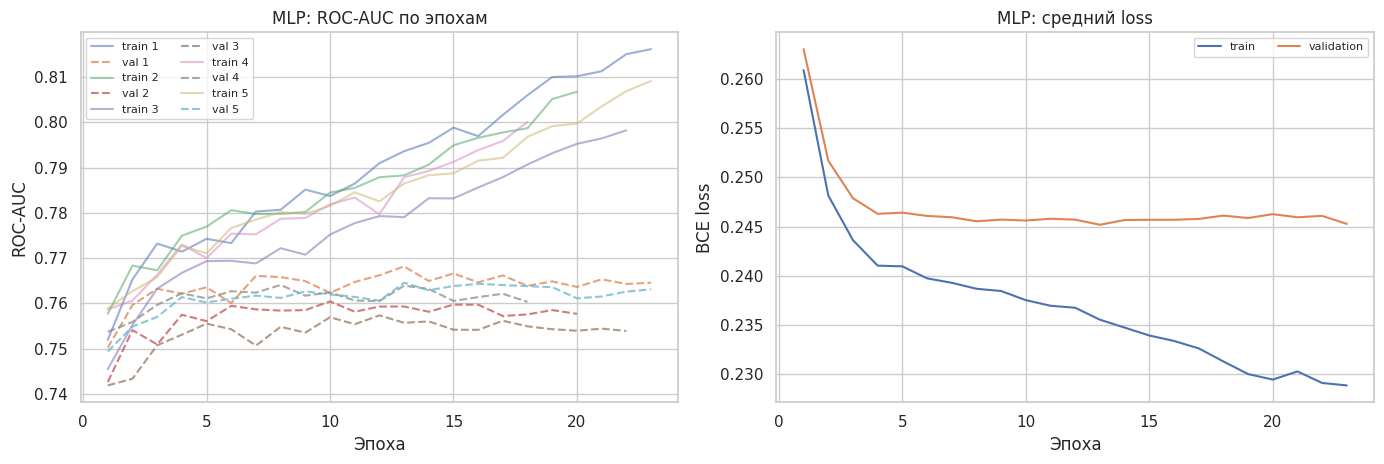

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

for fold, group in mlp_history.groupby('fold'):
    axes[0].plot(
        group['epoch'],
        group['train_auc'],
        alpha=0.55,
        label=f'train {fold}',
    )
    axes[0].plot(
        group['epoch'],
        group['stop_auc'],
        linestyle='--',
        alpha=0.75,
        label=f'val {fold}',
    )

axes[0].set(
    title='MLP: ROC-AUC по эпохам',
    xlabel='Эпоха',
    ylabel='ROC-AUC',
)

mean_history = (
    mlp_history
    .groupby('epoch', as_index=False)
    .agg(train_loss=('train_loss', 'mean'),
         stop_loss=('stop_loss', 'mean'))
)
axes[1].plot(
    mean_history['epoch'],
    mean_history['train_loss'],
    label='train',
)
axes[1].plot(
    mean_history['epoch'],
    mean_history['stop_loss'],
    label='validation',
)
axes[1].set(
    title='MLP: средний loss',
    xlabel='Эпоха',
    ylabel='BCE loss',
)

for ax in axes:
    ax.legend(ncol=2, fontsize=8)

fig.tight_layout()
plt.show()

## 9. Сравнение моделей

Теперь все основные алгоритмы имеют OOF-прогнозы на одних и тех же объектах. В сводке специально оставляю и логистическую регрессию: она служит простым линейным baseline, относительно которого видно, сколько даёт переход к нелинейной модели, а затем — сколько добавляет подробная кредитная история.

Сначала сравниваю модели по ROC-AUC, PR-AUC, Brier score и времени обучения, затем смотрю ROC/PR-кривые и калибровку вероятностей.

In [29]:
comparison_rows = [
    {
        'model': 'Логистическая регрессия',
        'seconds': classic_results.loc[
            classic_results['model'].eq('Логистическая регрессия'),
            'seconds',
        ].iloc[0],
        **classic_metrics['Логистическая регрессия'],
    },
    {
        'model': 'Одиночное дерево',
        'seconds': classic_results.loc[
            classic_results['model'].eq('Одиночное дерево'),
            'seconds',
        ].iloc[0],
        **classic_metrics['Одиночное дерево'],
    },
    {
        'model': 'LightGBM — только анкета',
        'seconds': application_lgbm_folds['seconds'].sum(),
        **application_lgbm_metrics,
    },
    {
        'model': 'LightGBM — анкета + история',
        'seconds': lgbm_folds['seconds'].sum(),
        **lgbm_metrics,
    },
    {
        'model': 'CatBoost — анкета + история',
        'seconds': cat_folds['seconds'].sum(),
        **cat_metrics,
    },
    {
        'model': 'MLP — анкета + история',
        'seconds': mlp_folds['seconds'].sum(),
        **mlp_metrics,
    },
]

comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values('roc_auc', ascending=False)
    .reset_index(drop=True)
)

display(
    comparison.style.format({
        'roc_auc': '{:.5f}',
        'pr_auc': '{:.5f}',
        'brier': '{:.5f}',
        'seconds': '{:.1f}',
    }).set_caption('5-fold OOF: итоговое сравнение')
)

,model,seconds,roc_auc,pr_auc,brier
0,CatBoost — анкета + история,1384.7,0.79405,0.28957,0.06541
1,LightGBM — анкета + история,369.2,0.78538,0.27810,0.06606
2,LightGBM — только анкета,39.2,0.76724,0.25312,0.06731
3,MLP — анкета + история,288.9,0.76318,0.24636,0.06757
4,Логистическая регрессия,874.7,0.75141,0.23143,0.20208
5,Одиночное дерево,61.4,0.72805,0.20346,0.20827


Сводка хорошо показывает, откуда пришёл основной прирост качества. Логистическая регрессия даёт `0.75141`, LightGBM только по анкете — `0.76724`, а после подключения истории — `0.78538`. Лучшей самостоятельной моделью становится CatBoost с **0.79405 ROC-AUC**, `0.28957` PR-AUC и `0.06541` Brier score.

То есть основной отрыв дали три последовательных решения: переход к нелинейному ансамблю, добавление подробной истории и затем замена LightGBM на CatBoost. MLP при этом остаётся ниже даже LightGBM только по анкете.

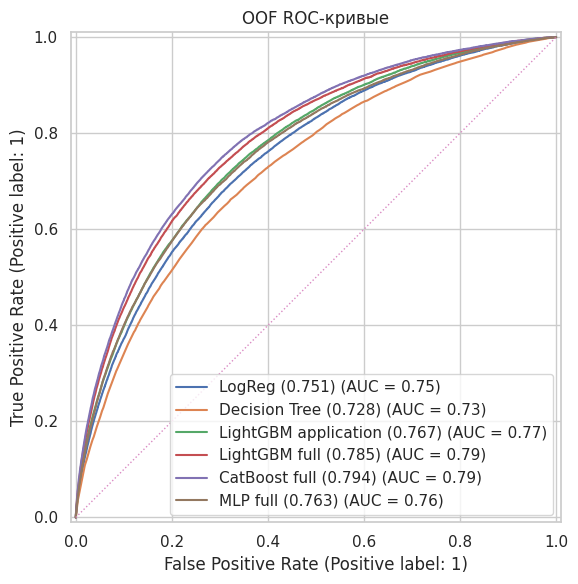

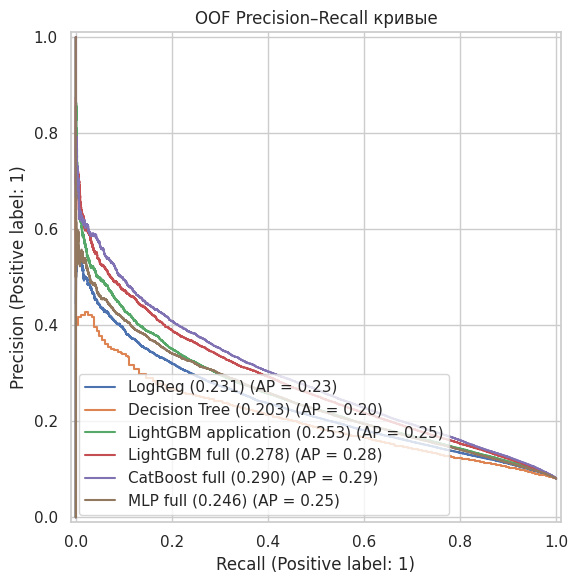

In [30]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

prediction_map = {
    'LogReg': logreg_oof,
    'Decision Tree': tree_oof,
    'LightGBM application': application_oof,
    'LightGBM full': lgbm_oof,
    'CatBoost full': cat_oof,
    'MLP full': mlp_oof,
}

fig, ax = plt.subplots(figsize=(8, 6))
for name, probability in prediction_map.items():
    RocCurveDisplay.from_predictions(
        target,
        probability,
        name=f'{name} ({roc_auc_score(target, probability):.3f})',
        ax=ax,
    )
ax.plot([0, 1], [0, 1], linestyle=':', linewidth=1)
ax.set_title('OOF ROC-кривые')
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
for name, probability in prediction_map.items():
    PrecisionRecallDisplay.from_predictions(
        target,
        probability,
        name=f'{name} ({average_precision_score(target, probability):.3f})',
        ax=ax,
    )
ax.set_title('OOF Precision–Recall кривые')
fig.tight_layout()
plt.show()

ROC- и Precision–Recall кривые подтверждают табличное сравнение: CatBoost и LightGBM с историей проходят выше простых моделей на большей части диапазона порогов. Разница особенно заметна на PR-кривой, что важно при доле дефолтов около 8%.

Это показывает, что исторические признаки улучшают не только общую способность ранжировать клиентов, но и качество работы именно с редким дефолтным классом.

### 9.1. Калибровка вероятностей

ROC-AUC показывает ранжирование, но для скоринга полезно видеть, насколько прогноз похож на вероятность. В первом MLP сильное взвешивание классов сильно испортило калибровку; после изменения loss проверяю это отдельно.

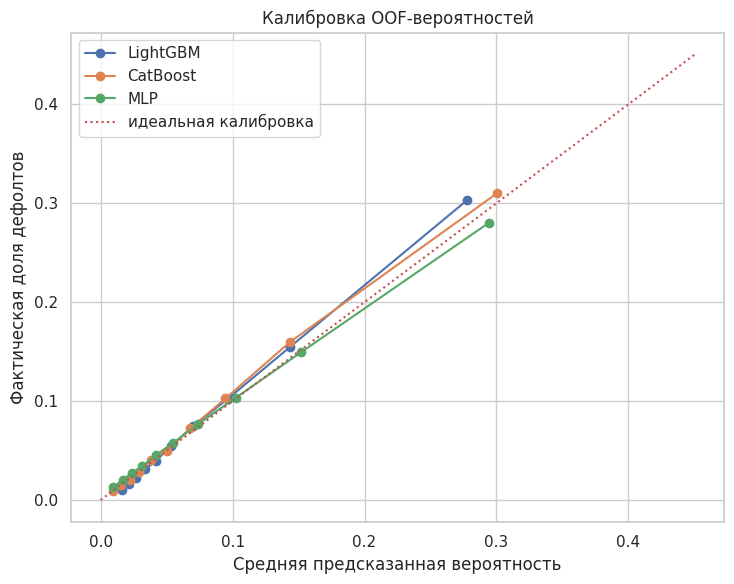

In [31]:
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(7.5, 6))

for name, probability in {
    'LightGBM': lgbm_oof,
    'CatBoost': cat_oof,
    'MLP': mlp_oof,
}.items():
    observed, predicted = calibration_curve(
        target,
        probability,
        n_bins=10,
        strategy='quantile',
    )
    ax.plot(predicted, observed, marker='o', label=name)

ax.plot([0, 0.45], [0, 0.45], linestyle=':', label='идеальная калибровка')
ax.set(
    title='Калибровка OOF-вероятностей',
    xlabel='Средняя предсказанная вероятность',
    ylabel='Фактическая доля дефолтов',
)
ax.legend()
fig.tight_layout()
plt.show()

По Brier score CatBoost также оказывается лучшим среди сильных моделей: `0.06541` против `0.06606` у LightGBM и `0.06757` у MLP. Разница небольшая, но она показывает, что преимущество CatBoost не ограничивается только ROC-AUC.

При этом калибровочная диаграмма здесь используется как диагностика. Для реального кредитного продукта вероятности всё равно потребовали бы отдельной калибровки и проверки на более новых временных когортах.

### 9.2. Ансамбль второго уровня

Просто подобрать веса CatBoost и LightGBM на полном OOF и на нём же показать прирост было бы слишком оптимистично: веса и оценка использовали бы одни и те же `TARGET`.

Поэтому здесь используется второй уровень 5-fold CV. На каждом meta-fold вес LightGBM выбирается только на четырёх пятых OOF-прогнозов, а качество измеряется на оставшейся пятой части. После пяти meta-fold получается отдельный **cross-fitted blend OOF**, в котором каждый объект оценён весом, выбранным без его `TARGET`.

Для test итоговый вес берётся как среднее пяти весов, найденных на meta-train частях. Так можно честно проверить, даёт ли смешивание моделей устойчивый прирост относительно одного CatBoost.

In [32]:
def cross_fitted_blend(
    cat_oof,
    lgb_oof,
    y,
    cat_test,
    lgb_test,
    lgb_weights=None,
):
    """Подбирает вес LightGBM внутри meta-train и оценивает его на meta-validation."""
    if lgb_weights is None:
        lgb_weights = np.round(np.linspace(0.0, 1.0, 21), 2)

    meta_splitter = StratifiedKFold(
        n_splits=META_N_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE + 100,
    )

    blend_oof = np.zeros(len(y), dtype='float64')
    selected_weights = []
    fold_rows = []

    for meta_fold, (meta_train_idx, meta_valid_idx) in enumerate(
        meta_splitter.split(np.zeros(len(y)), y),
        start=1,
    ):
        train_scores = []

        for lgb_weight in lgb_weights:
            cat_weight = 1.0 - lgb_weight
            train_probability = (
                cat_weight * cat_oof[meta_train_idx]
                + lgb_weight * lgb_oof[meta_train_idx]
            )
            train_scores.append(
                roc_auc_score(
                    y.iloc[meta_train_idx],
                    train_probability,
                )
            )

        best_position = int(np.argmax(train_scores))
        best_lgb_weight = float(lgb_weights[best_position])
        best_cat_weight = 1.0 - best_lgb_weight
        selected_weights.append(best_lgb_weight)

        valid_probability = (
            best_cat_weight * cat_oof[meta_valid_idx]
            + best_lgb_weight * lgb_oof[meta_valid_idx]
        )
        blend_oof[meta_valid_idx] = valid_probability

        fold_metrics = model_metrics(
            y.iloc[meta_valid_idx],
            valid_probability,
        )
        fold_rows.append({
            'meta_fold': meta_fold,
            'catboost_weight': best_cat_weight,
            'lightgbm_weight': best_lgb_weight,
            'meta_train_best_auc': train_scores[best_position],
            **fold_metrics,
        })

    final_lgb_weight = float(np.mean(selected_weights))
    final_cat_weight = 1.0 - final_lgb_weight
    blend_test = (
        final_cat_weight * cat_test
        + final_lgb_weight * lgb_test
    )

    return (
        blend_oof,
        blend_test,
        pd.DataFrame(fold_rows),
        model_metrics(y, blend_oof),
        final_cat_weight,
        final_lgb_weight,
    )


(
    blend_oof,
    blend_test,
    blend_meta_folds,
    blend_metrics,
    final_cat_weight,
    final_lgb_weight,
) = cross_fitted_blend(
    cat_oof,
    lgbm_oof,
    target,
    cat_test,
    lgbm_test,
)

display(
    blend_meta_folds.style.format({
        'catboost_weight': '{:.2f}',
        'lightgbm_weight': '{:.2f}',
        'meta_train_best_auc': '{:.5f}',
        'roc_auc': '{:.5f}',
        'pr_auc': '{:.5f}',
        'brier': '{:.5f}',
    }).set_caption(
        'Второй уровень CV: подбор веса только на meta-train'
    )
)

blend_comparison = pd.DataFrame([
    {
        'model': 'CatBoost',
        **cat_metrics,
    },
    {
        'model': 'Cross-fitted CatBoost + LightGBM',
        **blend_metrics,
    },
])
blend_comparison['delta_roc_auc_vs_catboost'] = (
    blend_comparison['roc_auc']
    - cat_metrics['roc_auc']
)

display(
    blend_comparison.style.format({
        'roc_auc': '{:.5f}',
        'pr_auc': '{:.5f}',
        'brier': '{:.5f}',
        'delta_roc_auc_vs_catboost': '{:+.5f}',
    }).set_caption(
        'Независимая OOF-оценка ансамбля второго уровня'
    )
)

print(
    'Средний вес для test: '
    f'CatBoost={final_cat_weight:.2f}, '
    f'LightGBM={final_lgb_weight:.2f}'
)

# Для интерпретации основной моделью остаётся CatBoost:
# у него есть собственные SHAP/importance и понятная структура.
final_oof = cat_oof
final_test = cat_test

# Для Kaggle сохраняю и CatBoost, и честный cross-fitted blend.
submission_cat = test_matrix[['SK_ID_CURR']].copy()
submission_cat['TARGET'] = cat_test
submission_cat.to_csv(
    SUBMISSIONS_DIR / 'submission_catboost_v2.csv',
    index=False,
)

submission_blend = test_matrix[['SK_ID_CURR']].copy()
submission_blend['TARGET'] = blend_test
submission_blend.to_csv(
    SUBMISSIONS_DIR / 'submission_crossfitted_blend_v2.csv',
    index=False,
)

# Самая наглядная сводка всей логики проекта.
progression = pd.DataFrame([
    {
        'step': 'Логистическая регрессия — только заявка',
        'roc_auc': classic_metrics['Логистическая регрессия']['roc_auc'],
    },
    {
        'step': 'LightGBM — только заявка',
        'roc_auc': application_lgbm_metrics['roc_auc'],
    },
    {
        'step': 'LightGBM — заявка + история',
        'roc_auc': lgbm_metrics['roc_auc'],
    },
    {
        'step': 'CatBoost — заявка + история',
        'roc_auc': cat_metrics['roc_auc'],
    },
    {
        'step': 'Cross-fitted CatBoost + LightGBM',
        'roc_auc': blend_metrics['roc_auc'],
    },
])
progression['delta_vs_previous'] = progression['roc_auc'].diff()
progression['delta_vs_logreg'] = (
    progression['roc_auc']
    - progression.loc[0, 'roc_auc']
)

display(
    progression.style.format({
        'roc_auc': '{:.5f}',
        'delta_vs_previous': '{:+.5f}',
        'delta_vs_logreg': '{:+.5f}',
    }).set_caption(
        'Как последовательно менялось качество решения'
    )
)

print('Submission-файлы сохранены:')
print('- submission_catboost_v2.csv')
print('- submission_crossfitted_blend_v2.csv')

,meta_fold,catboost_weight,lightgbm_weight,meta_train_best_auc,roc_auc,pr_auc,brier
0,1,0.80,0.20,0.79441,0.79448,0.28952,0.06539
1,2,0.80,0.20,0.79419,0.79535,0.29964,0.06505
2,3,0.85,0.15,0.79425,0.79507,0.27981,0.06573
3,4,0.80,0.20,0.79400,0.79609,0.29277,0.06532
4,5,0.85,0.15,0.79527,0.79105,0.29322,0.06531


,model,roc_auc,pr_auc,brier,delta_roc_auc_vs_catboost
0,CatBoost,0.79405,0.28957,0.06541,+0.00000
1,Cross-fitted CatBoost + LightGBM,0.79440,0.29067,0.06536,+0.00035


Средний вес для test: CatBoost=0.82, LightGBM=0.18


,step,roc_auc,delta_vs_previous,delta_vs_logreg
0,Логистическая регрессия — только заявка,0.75141,+nan,+0.00000
1,LightGBM — только заявка,0.76724,+0.01583,+0.01583
2,LightGBM — заявка + история,0.78538,+0.01814,+0.03397
3,CatBoost — заявка + история,0.79405,+0.00867,+0.04264
4,Cross-fitted CatBoost + LightGBM,0.79440,+0.00035,+0.04299


Submission-файлы сохранены:
- submission_catboost_v2.csv
- submission_crossfitted_blend_v2.csv


Второй уровень CV выбирал для LightGBM вес `0.15–0.20`; средний итоговый вес для test составил **0.18 LightGBM и 0.82 CatBoost**. Cross-fitted ансамбль получил **0.79440 ROC-AUC**, то есть всего `+0.00035` относительно CatBoost.

Локально прирост есть, но он очень маленький. Внешняя проверка на Kaggle его не подтвердила: CatBoost получил `0.79510` Private и `0.79479` Public, а blend — `0.79473` Private и `0.79466` Public. Поэтому финальной моделью оставлен CatBoost, а ансамбль рассматривается как корректно проверенный дополнительный эксперимент.

## 10. Анализ финальной модели CatBoost

Cross-fitted blend немного выше по локальному OOF (`0.79440` против `0.79405`), но внешний Kaggle результат этого преимущества не подтвердил. CatBoost получил `0.79510` Private и `0.79479` Public, тогда как blend — `0.79473` и `0.79466`.

Поэтому финальной моделью остаётся **CatBoost**. Это лучшая самостоятельная модель и одновременно лучший вариант на скрытом private leaderboard. Для неё дальше анализируются рабочий порог, ошибки, вклад источников данных, отдельные признаки, SHAP и fairness.

### 10.1. Рабочий порог и ошибки

Порог `0.5` для этого датасета слишком высокий: дефолтный класс редкий. Для диагностического анализа выбираю порог по максимуму F1 на OOF-прогнозах CatBoost и уже при нём смотрю precision, recall и confusion matrix. Этот порог не используется для расчёта ROC-AUC и не нужен для Kaggle submission.

,значение
Порог,0.1499
Precision,0.2779
Recall / TPR,0.4722
F1,0.3499
FPR,0.1078
FN,"13,102.0000"
FP,"30,468.0000"


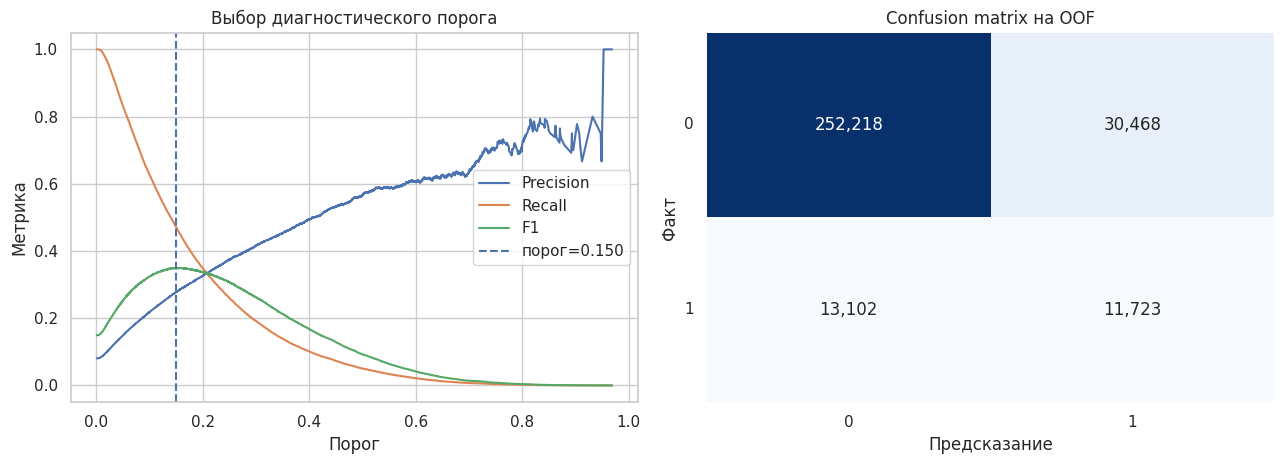

In [33]:
precision, recall, thresholds = precision_recall_curve(target, final_oof)
f1_values = (
    2 * precision * recall
    / np.clip(precision + recall, 1e-12, None)
)

best_index = int(np.nanargmax(f1_values[:-1]))
operating_threshold = float(thresholds[best_index])

final_prediction = (final_oof >= operating_threshold).astype('int8')

tn, fp, fn, tp = confusion_matrix(
    target,
    final_prediction,
).ravel()

threshold_metrics = pd.Series({
    'Порог': operating_threshold,
    'Precision': precision_score(target, final_prediction),
    'Recall / TPR': recall_score(target, final_prediction),
    'F1': f1_score(target, final_prediction),
    'FPR': fp / (fp + tn),
    'FN': fn,
    'FP': fp,
})

display(threshold_metrics.to_frame('значение'))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].plot(thresholds, precision[:-1], label='Precision')
axes[0].plot(thresholds, recall[:-1], label='Recall')
axes[0].plot(thresholds, f1_values[:-1], label='F1')
axes[0].axvline(
    operating_threshold,
    linestyle='--',
    label=f'порог={operating_threshold:.3f}',
)
axes[0].set(
    title='Выбор диагностического порога',
    xlabel='Порог',
    ylabel='Метрика',
)
axes[0].legend()

sns.heatmap(
    np.array([[tn, fp], [fn, tp]]),
    annot=True,
    fmt=',d',
    cmap='Blues',
    cbar=False,
    ax=axes[1],
)
axes[1].set(
    title='Confusion matrix на OOF',
    xlabel='Предсказание',
    ylabel='Факт',
)
axes[1].set_xticklabels(['0', '1'])
axes[1].set_yticklabels(['0', '1'], rotation=0)

fig.tight_layout()
plt.show()

Максимум F1 достигается при пороге около **0.1499**, а не при стандартных `0.5`. При нём precision составляет `0.2779`, recall — `0.4722`, F1 — `0.3499`. Модель находит примерно 47% дефолтов, но при этом получает 30 468 ложных срабатываний и пропускает 13 102 дефолта.

Такой порог нужен только для содержательного анализа ошибок. В реальном кредитном продукте его следует выбирать по стоимости FP/FN и бизнес-ограничениям; для ROC-AUC и Kaggle submission бинарный порог вообще не используется.

### 10.2. Какие клиенты дают FP и FN

Смотрю не отдельные ID, а профили ошибок: возраст, отношение кредита к доходу и средний внешний скоринг. Это помогает понять, чем ложные срабатывания отличаются от пропущенных дефолтов.

In [34]:
error_frame = application_train[[
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'DAYS_BIRTH',
    'EXT_SOURCE_1',
    'EXT_SOURCE_2',
    'EXT_SOURCE_3',
]].copy()

error_frame['target'] = target.to_numpy()
error_frame['probability'] = final_oof
error_frame['prediction'] = final_prediction
error_frame['age_years'] = -error_frame['DAYS_BIRTH'] / 365.25
error_frame['credit_to_income'] = safe_ratio(
    error_frame['AMT_CREDIT'],
    error_frame['AMT_INCOME_TOTAL'],
)
error_frame['ext_source_mean'] = error_frame[
    ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
].mean(axis=1)

error_frame['error_type'] = np.select(
    [
        (error_frame['target'] == 1) & (error_frame['prediction'] == 1),
        (error_frame['target'] == 0) & (error_frame['prediction'] == 0),
        (error_frame['target'] == 0) & (error_frame['prediction'] == 1),
        (error_frame['target'] == 1) & (error_frame['prediction'] == 0),
    ],
    ['TP', 'TN', 'FP', 'FN'],
    default='OTHER',
)

error_summary = (
    error_frame
    .groupby('error_type', observed=True)
    .agg(
        n=('target', 'size'),
        mean_probability=('probability', 'mean'),
        median_age=('age_years', 'median'),
        median_credit_to_income=('credit_to_income', 'median'),
        median_ext_source=('ext_source_mean', 'median'),
    )
    .reindex(['TP', 'TN', 'FP', 'FN'])
)

display(
    error_summary.style.format({
        'mean_probability': '{:.3f}',
        'median_age': '{:.1f}',
        'median_credit_to_income': '{:.2f}',
        'median_ext_source': '{:.3f}',
    })
)

,n,mean_probability,median_age,median_credit_to_income,median_ext_source
error_type,,,,,
TP,11723,0.306,36.7,3.19,0.304
TN,252218,0.046,44.3,3.28,0.553
FP,30468,0.248,36.6,3.18,0.327
FN,13102,0.075,41.7,3.33,0.485


Профили ошибок хорошо объясняют, где модели сложнее всего. У FP медианный `EXT_SOURCE` около `0.327`, то есть эти хорошие клиенты по внешнему скорингу выглядят скорее как рискованные. У FN медианный `EXT_SOURCE` уже около `0.485`: часть реальных дефолтов выглядит для модели заметно надёжнее, поэтому она их пропускает.

Возраст и отношение кредита к доходу разделяют типы ошибок слабее. Основное различие между TP/FP и TN/FN здесь заметнее именно по прогнозу модели и внешним скоринговым признакам.

### 10.3. Что именно даёт кредитная история

Чтобы понять вклад дополнительных таблиц, использую **group permutation importance** на внешних OOF-фолдах CatBoost.

Для каждого фолда сначала считаю обычный ROC-AUC на объектах, которые модель не видела при обучении. Затем у этих же объектов совместно перемешиваю все признаки одной группы и пересчитываю ROC-AUC. Если качество заметно падает, значит модель действительно использует информацию этой группы.

Сначала проверяются источники данных: анкета, bureau, прошлые заявки, POS, installments и кредитные карты. Отдельно проверяются семейства новых v2-признаков: временные окна, последние 1/3/5 событий, двухуровневые агрегаты по отдельным договорам и новые взаимодействия анкеты.

Признаки внутри группы переставляются **одним и тем же порядком строк**, чтобы сохранить их внутренние взаимосвязи. Importance считается на каждом из пяти внешних фолдов, поэтому итоговая таблица показывает среднее падение ROC-AUC и разброс между фолдами без повторного обучения моделей.

,group,n_features,baseline_auc,permuted_auc,auc_drop_mean,auc_drop_std
0,Источник: текущая заявка,162,0.79413,0.63999,+0.15414,0.00263
1,V2: все новые признаки,1082,0.79413,0.75432,+0.03981,0.00273
2,Источник: bureau,1160,0.79413,0.77436,+0.01977,0.00125
3,Источник: installments,213,0.79413,0.77712,+0.01701,0.00201
4,V2: недавние временные окна,798,0.79413,0.77783,+0.01630,0.00046
5,Источник: previous_application,679,0.79413,0.77921,+0.01491,0.00136
6,Источник: POS_CASH,187,0.79413,0.78680,+0.00732,0.00079
7,Источник: credit_card,307,0.79413,0.78804,+0.00609,0.00047
8,V2: новые взаимодействия анкеты,9,0.79413,0.78901,+0.00511,0.00094
9,V2: агрегаты отдельных договоров,138,0.79413,0.79189,+0.00224,0.00050


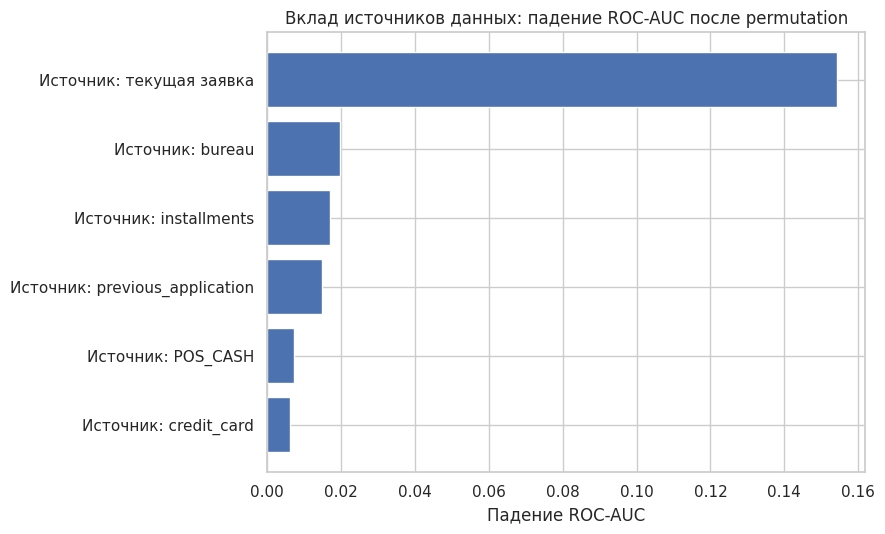

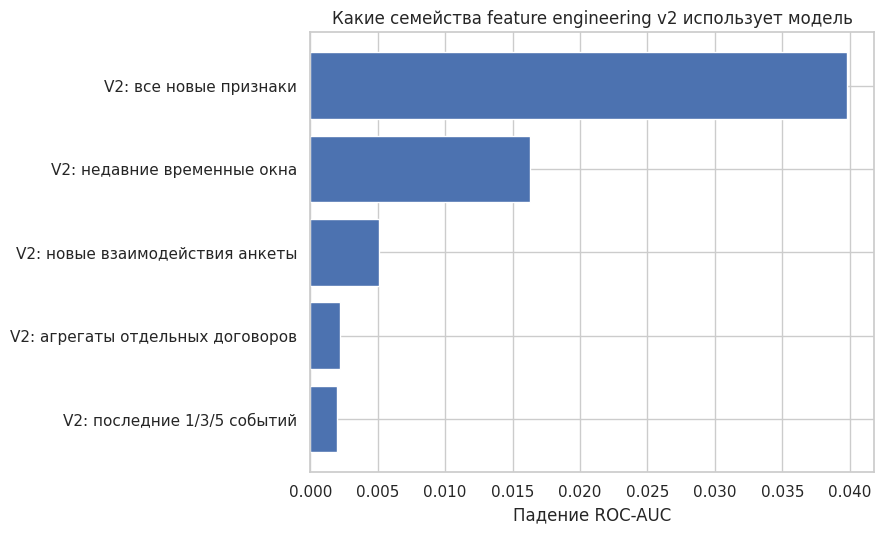

In [35]:
def catboost_ready_frame(frame, categorical_features):
    result = frame.copy()
    for column in categorical_features:
        if column in result.columns:
            result[column] = result[column].astype(str)
    return result


def make_permutation_groups(columns):
    columns = list(columns)
    history_prefixes = (
        'BUREAU',
        'PREVIOUS',
        'POS',
        'INSTALLMENTS',
        'CREDIT_CARD',
    )

    source_groups = {
        'Источник: текущая заявка': [
            column for column in columns
            if not column.startswith(history_prefixes)
        ],
        'Источник: bureau': [
            column for column in columns
            if column.startswith('BUREAU')
        ],
        'Источник: previous_application': [
            column for column in columns
            if column.startswith('PREVIOUS')
        ],
        'Источник: POS_CASH': [
            column for column in columns
            if column.startswith('POS')
        ],
        'Источник: installments': [
            column for column in columns
            if column.startswith('INSTALLMENTS')
        ],
        'Источник: credit_card': [
            column for column in columns
            if column.startswith('CREDIT_CARD')
        ],
    }

    v2_groups = {
        'V2: все новые признаки': [
            column for column in columns
            if '_V2_' in column
        ],
        'V2: недавние временные окна': [
            column for column in columns
            if '_V2_RECENT_' in column
        ],
        'V2: последние 1/3/5 событий': [
            column for column in columns
            if '_V2_LAST_' in column
        ],
        'V2: агрегаты отдельных договоров': [
            column for column in columns
            if (
                '_V2_CONTRACT' in column
                or '_V2_CLIENT' in column
            )
        ],
        'V2: новые взаимодействия анкеты': [
            column for column in columns
            if column.startswith('APP__V2_')
        ],
    }

    return {
        **source_groups,
        **v2_groups,
    }


def group_permutation_importance_cv(
    models,
    X_input,
    y,
    categorical_features,
    groups,
    repeats=PERMUTATION_REPEATS,
):
    rows = []
    folds = make_folds(y)

    for fold, ((_, valid_idx), model) in enumerate(
        zip(folds, models),
        start=1,
    ):
        X_valid = catboost_ready_frame(
            X_input.iloc[valid_idx],
            categorical_features,
        )
        y_valid = y.iloc[valid_idx]

        baseline_probability = model.predict_proba(X_valid)[:, 1]
        baseline_auc = roc_auc_score(
            y_valid,
            baseline_probability,
        )

        for group_position, (group_name, group_columns) in enumerate(
            groups.items(),
            start=1,
        ):
            available = [
                column for column in group_columns
                if column in X_valid.columns
            ]
            if not available:
                continue

            for repeat in range(repeats):
                rng = np.random.default_rng(
                    RANDOM_STATE
                    + 10_000 * fold
                    + 100 * group_position
                    + repeat
                )
                order = rng.permutation(len(X_valid))

                permuted = X_valid.copy()
                for column in available:
                    permuted[column] = (
                        X_valid[column]
                        .to_numpy(copy=False)[order]
                    )

                probability = model.predict_proba(permuted)[:, 1]
                permuted_auc = roc_auc_score(
                    y_valid,
                    probability,
                )

                rows.append({
                    'fold': fold,
                    'group': group_name,
                    'n_features': len(available),
                    'baseline_auc': baseline_auc,
                    'permuted_auc': permuted_auc,
                    'auc_drop': baseline_auc - permuted_auc,
                })

                del permuted, probability
                gc.collect()

        del X_valid, baseline_probability
        gc.collect()

    details = pd.DataFrame(rows)
    summary = (
        details
        .groupby('group', as_index=False)
        .agg(
            n_features=('n_features', 'first'),
            baseline_auc=('baseline_auc', 'mean'),
            permuted_auc=('permuted_auc', 'mean'),
            auc_drop_mean=('auc_drop', 'mean'),
            auc_drop_std=('auc_drop', 'std'),
        )
        .sort_values('auc_drop_mean', ascending=False)
        .reset_index(drop=True)
    )
    return summary, details


permutation_groups = make_permutation_groups(X.columns)

permutation_summary, permutation_details = (
    group_permutation_importance_cv(
        cat_models,
        X,
        target,
        categorical_columns,
        permutation_groups,
    )
)

display(
    permutation_summary.style.format({
        'baseline_auc': '{:.5f}',
        'permuted_auc': '{:.5f}',
        'auc_drop_mean': '{:+.5f}',
        'auc_drop_std': '{:.5f}',
    }).set_caption(
        'Group permutation importance по пяти OOF-фолдам CatBoost'
    )
)

source_importance = permutation_summary[
    permutation_summary['group'].str.startswith('Источник:')
].sort_values('auc_drop_mean')

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(
    source_importance['group'],
    source_importance['auc_drop_mean'],
)
ax.set(
    title='Вклад источников данных: падение ROC-AUC после permutation',
    xlabel='Падение ROC-AUC',
    ylabel='',
)
fig.tight_layout()
plt.show()

v2_importance = permutation_summary[
    permutation_summary['group'].str.startswith('V2:')
].sort_values('auc_drop_mean')

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(
    v2_importance['group'],
    v2_importance['auc_drop_mean'],
)
ax.set(
    title='Какие семейства feature engineering v2 использует модель',
    xlabel='Падение ROC-AUC',
    ylabel='',
)
fig.tight_layout()
plt.show()

permutation_summary.to_csv(
    OUTPUT_DIR / 'reports' / 'group_permutation_importance_v2.csv',
    index=False,
)

Групповой permutation importance показывает, что среди исторических источников наибольший дополнительный сигнал дают **bureau** (`−0.01977 ROC-AUC` после перемешивания), **installments** (`−0.01701`) и **previous_application** (`−0.01491`). POS и кредитные карты тоже используются моделью, но их вклад меньше.

Новые признаки v2 действительно оказались полезными: совместное перемешивание всех 1 082 новых признаков снижает ROC-AUC примерно на `0.03981`. Самое сильное семейство внутри v2 — **недавние временные окна** (`−0.01630`). Новые взаимодействия анкеты, агрегаты отдельных договоров и последние 1/3/5 событий тоже дают сигнал, но меньший.

Эти значения нельзя складывать: группы пересекаются и признаки внутри них коррелируют. Permutation importance здесь показывает зависимость модели от конкретной группы при наличии остальных признаков, а не раскладывает общий ROC-AUC на независимые части.

### 10.4. Какие отдельные признаки использует CatBoost

Групповой permutation importance показывает вклад целого источника или семейства агрегатов, но не отвечает, какие конкретные признаки внутри группы наиболее заметны модели. Для этого дополнительно смотрю встроенный feature importance CatBoost и SHAP на случайной подвыборке.

SHAP здесь интерпретируется как описание поведения уже обученной модели, а не как доказательство причинного влияния признака на дефолт.

,feature,importance
140,APP__EXT_SOURCE_MEAN,6.6378
142,APP__EXT_SOURCE_MIN,1.7486
143,APP__EXT_SOURCE_MAX,1.6822
150,APP__V2_EXT_MEAN_X_AGE,1.6070
1,CODE_GENDER,0.8743
148,APP__V2_EXT_2_X_3,0.8466
40,EXT_SOURCE_2,0.7816
137,APP__V2_CREDIT_GOODS_GAP,0.7657
11,NAME_EDUCATION_TYPE,0.7430
16,DAYS_EMPLOYED,0.6585


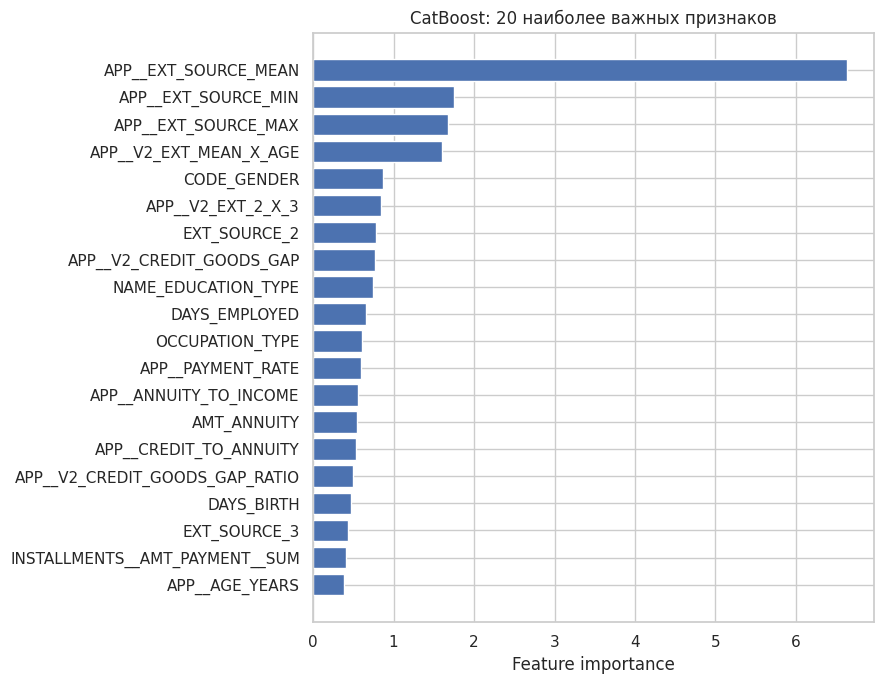

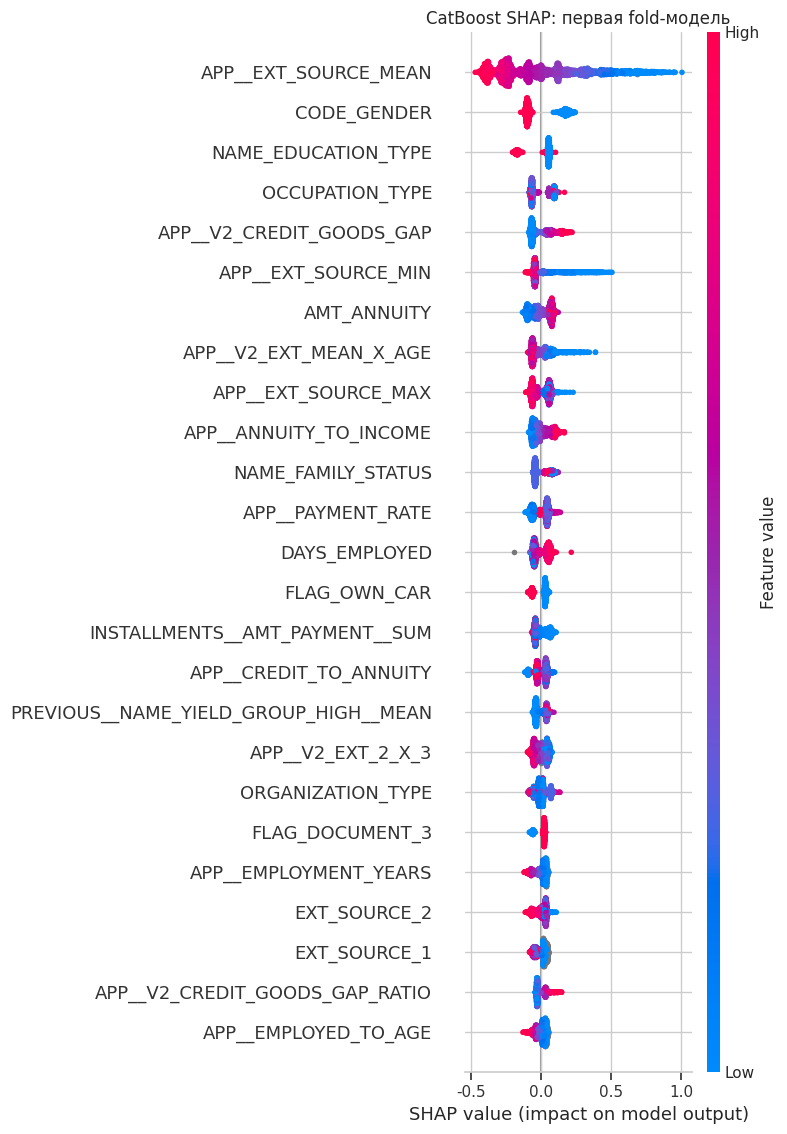

In [36]:
from catboost import Pool
import shap

cat_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': cat_models[0].get_feature_importance(),
}).sort_values('importance', ascending=False)

display(cat_importance.head(25))

fig, ax = plt.subplots(figsize=(9, 7))
top_importance = cat_importance.head(20).sort_values('importance')
ax.barh(top_importance['feature'], top_importance['importance'])
ax.set(
    title='CatBoost: 20 наиболее важных признаков',
    xlabel='Feature importance',
    ylabel='',
)
fig.tight_layout()
plt.show()

sample = X.sample(
    min(3000, len(X)),
    random_state=RANDOM_STATE,
)
sample_for_catboost = sample.copy()

cat_columns = [
    column for column in categorical_columns
    if column in sample_for_catboost.columns
]
for column in cat_columns:
    sample_for_catboost[column] = sample_for_catboost[column].astype(str)

cat_indices = [
    sample_for_catboost.columns.get_loc(column)
    for column in cat_columns
]

sample_pool = Pool(
    sample_for_catboost,
    cat_features=cat_indices,
)

cat_shap_values = cat_models[0].get_feature_importance(
    sample_pool,
    type='ShapValues',
)[:, :-1]

shap.summary_plot(
    cat_shap_values,
    sample,
    max_display=25,
    show=False,
)
plt.title('CatBoost SHAP: первая fold-модель')
plt.tight_layout()
plt.show()

По встроенному importance CatBoost главным признаком становится агрегированный `APP__EXT_SOURCE_MEAN`. Высоко находятся также минимум и максимум `EXT_SOURCE`, возрастные взаимодействия, отдельные внешние скоринги и финансовые отношения.

Среди новых признаков v2 в верхней части списка появились `APP__V2_EXT_MEAN_X_AGE`, взаимодействие `EXT_SOURCE_2 × EXT_SOURCE_3` и признаки разницы между размером кредита и стоимостью товара. Из исторических агрегатов в top-25 попадает сумма фактических платежей по installments. SHAP дополняет эту картину, показывая распределение вклада признаков по отдельным объектам; это описание поведения модели, а не причинная интерпретация.

### 10.5. Fairness по полу и возрасту

Для всех групп использую один и тот же глобальный порог, выбранный выше. Сравниваю не только ROC-AUC, но и TPR/FPR. Различия между группами описывают поведение модели, но сами по себе не доказывают дискриминацию: у групп различается и исходная доля дефолтов.

In [37]:
sensitive = application_train[['CODE_GENDER', 'DAYS_BIRTH']].copy()
sensitive['age_group'] = pd.cut(
    -sensitive['DAYS_BIRTH'] / 365.25,
    [18, 25, 35, 45, 55, 65, 100],
    right=False,
)

fairness_rows = []

for dimension in ['CODE_GENDER', 'age_group']:
    for group, indices in sensitive.groupby(
        dimension,
        observed=True,
        dropna=False,
    ).groups.items():
        indices = np.asarray(list(indices))
        y_group = target.iloc[indices].to_numpy()
        p_group = final_oof[indices]

        if len(indices) < 100 or np.unique(y_group).size < 2:
            continue

        pred_group = (
            p_group >= operating_threshold
        ).astype('int8')

        tn_g, fp_g, fn_g, tp_g = confusion_matrix(
            y_group,
            pred_group,
        ).ravel()

        fairness_rows.append({
            'dimension': dimension,
            'group': str(group),
            'n': len(indices),
            'default_rate': y_group.mean(),
            'positive_rate': pred_group.mean(),
            'tpr': tp_g / (tp_g + fn_g),
            'fpr': fp_g / (fp_g + tn_g),
            'fnr': fn_g / (tp_g + fn_g),
            'roc_auc': roc_auc_score(y_group, p_group),
            'pr_auc': average_precision_score(y_group, p_group),
        })

fairness_results = pd.DataFrame(fairness_rows)

display(
    fairness_results.style.format({
        'default_rate': '{:.2%}',
        'positive_rate': '{:.2%}',
        'tpr': '{:.2%}',
        'fpr': '{:.2%}',
        'fnr': '{:.2%}',
        'roc_auc': '{:.5f}',
        'pr_auc': '{:.5f}',
    })
)

,dimension,group,n,default_rate,positive_rate,tpr,fpr,fnr,roc_auc,pr_auc
0,CODE_GENDER,F,202448,7.00%,10.74%,42.22%,8.38%,57.78%,0.79304,0.27043
1,CODE_GENDER,M,105059,10.14%,19.45%,53.88%,15.57%,46.12%,0.78518,0.31377
2,age_group,"[18, 25)",12233,12.29%,28.05%,57.51%,23.92%,42.49%,0.74466,0.29615
3,age_group,"[25, 35)",72429,10.66%,21.29%,55.90%,17.16%,44.10%,0.78579,0.32523
4,age_group,"[35, 45)",84261,8.41%,14.01%,47.96%,10.89%,52.04%,0.79865,0.30020
5,age_group,"[45, 55)",70190,7.05%,10.86%,43.29%,8.41%,56.71%,0.79222,0.27692
6,age_group,"[55, 65)",60522,5.42%,6.20%,29.44%,4.87%,70.56%,0.76361,0.20218
7,age_group,"[65, 100)",7876,3.66%,2.03%,12.85%,1.62%,87.15%,0.76892,0.15417


По полу качество различается умеренно: ROC-AUC около `0.7930` у женщин и `0.7852` у мужчин. При одном глобальном пороге TPR выше у мужчин (`53.9%` против `42.2%`), но одновременно выше и FPR (`15.6%` против `8.4%`). Это происходит на фоне разных исходных default rate: около `10.1%` у мужчин и `7.0%` у женщин.

По возрасту различия сильнее. ROC-AUC максимален примерно в группе 35–45 лет (`0.7987`), а у самых молодых составляет около `0.7447`. При фиксированном пороге TPR снижается с `57.5%` в группе 18–25 лет до `12.9%` после 65 лет. Эти результаты показывают неодинаковое поведение модели на подгруппах, но сами по себе не доказывают дискриминацию: группы отличаются по base rate, размеру и составу признаков.

## 11. Финальный результат

Работа начиналась с простого линейного baseline и последовательно усложнялась только после проверки предыдущего шага.

| Этап | OOF ROC-AUC | Прирост к предыдущему |
| --- | ---: | ---: |
| Логистическая регрессия — только заявка | 0.75141 | — |
| LightGBM — только заявка | 0.76724 | +0.01583 |
| LightGBM — заявка + история | 0.78538 | +0.01814 |
| CatBoost — заявка + история | **0.79405** | +0.00867 |
| Cross-fitted CatBoost + LightGBM | 0.79440 | +0.00035 |

Внешняя проверка на Kaggle:

| Submission | Public | Private |
| --- | ---: | ---: |
| **CatBoost v2** | **0.79479** | **0.79510** |
| Cross-fitted blend | 0.79466 | 0.79473 |

Главный результат проекта — не только итоговый score. Эксперимент показывает, откуда появляется качество:

- переход от линейной модели к ансамблю деревьев даёт около `+0.0158 ROC-AUC`;
- подробная кредитная и платёжная история добавляет LightGBM ещё `+0.0181`;
- CatBoost лучше использует большую разнородную матрицу и добавляет ещё `+0.0087`;
- среди исторических источников наиболее полезны bureau, installments и previous applications;
- среди новых признаков v2 сильнее всего работают недавние временные окна;
- ансамбль даёт лишь `+0.00035` на cross-fitted OOF и не улучшает внешний Kaggle score.

Поэтому финальной моделью выбран **CatBoost v2** с `0.79405` OOF ROC-AUC и `0.79510` Private Kaggle score. Локальная OOF-оценка и скрытый leaderboard находятся очень близко, что дополнительно подтверждает адекватность выбранной схемы валидации.

Работа остаётся учебным решением конкурсной задачи. Для реального кредитного скоринга дополнительно потребовались бы временная валидация, мониторинг drift, отдельная калибровка вероятностей, бизнес-функция стоимости ошибок и более глубокий fairness-аудит.